![Image in a markdown cell](https://cursos.utnba.centrodeelearning.com/pluginfile.php/1/theme_space/customlogo/1738330016/Logo%20UTN%20Horizontal.png)



# **Diplomado de Ciencia de Datos y Análisis Avanzado**
# **Unidad 5: Modelado Predictivo I**: Regresión y Clasificación

---


# **Proyecto: Predicción de Abandono de Clientes**

## **Curso:** Diplomado en Ciencia de Datos

# **Nombres de los Miembros del Equipo:**
### *   [Alexis Segarra]
### *   [Alfredo Chalabe]
### *   [Federico García]
### *   [Guido Miretti] (creador de esta versión de código del T.P.)
### *   [Alejandra Andrea Martinez]

# **Objetivo:**
## El objetivo de este proyecto es construir y evaluar varios modelos de clasificación para predecir si un cliente de una compañía de telecomunicaciones abandonará o no el servicio (churn). El rendimiento final del mejor modelo se medirá a través de la **métrica ROC AUC**.

---

# 0. **Configuración Inicial e Importación de Librerías**

## En esta sección, importaremos todas las librerías necesarias para el proyecto.


In [1]:
# Para manipulación de datos
import pandas as pd
import numpy as np
import itertools as iter

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Para preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Para modelado
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Para evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score

# Configuraciones adicionales para una mejor visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
# Ignorar warnings para una salida más limpia (opcional)
import warnings
warnings.filterwarnings('ignore')

# **Información del Dataset**

Utilizaremos el conjunto de datos "Telco Customer Churn". Este conjunto de datos contiene información demográfica de los clientes, los servicios que han contratado, información de su cuenta y si finalmente abandonó o no la compañía.

* **train.csv**: Datos para entrenar sus modelos. Incluye la variable objetivo Churn.
* **test.csv:** Datos para generar las predicciones. No incluye la variable Churn.

#  **1. Carga de Datos**

## Cargar los datasets proporcionado: `train.csv`, `test.csv`


In [2]:
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Asegúrate de que los archivos .csv estén en el mismo directorio que este cuaderno.")
    # Si usas Colab, puedes subir los archivos al entorno de ejecución.
    exit()

# La variable test_df solo se utilizará al final para generar las predicciones finales las cuales serán evaludas.
# La variable train_df será utilizada para todo el proceso de análisis, preprocesamiento, modelado y evaluación (la misma se dividirá en conjunto de train y test).

# 2**. Análisis Exploratorio de Datos (EDA)**

En esta fase, exploraremos el dataset de entrenamiento para entender mejor nuestros datos, encontrar patrones, identificar valores faltantes y visualizar relaciones entre las características y la variable objetivo (`Churn`).


In [3]:
# Obtenemos una visión general de los datos
print("Forma del dataset de entrenamiento:", train_df.shape)
print("Forma del dataset de prueba:", test_df.shape)

# Se aprecia que el conjunto train_df contiene la columna objetivo 'Churn' que indica si un cliente ha abandonado el servicio o no.
# Además, se observa que ambas tablas contienen varias columnas categóricas y numéricas y que no se cuenta con valores faltantes.
print("\nPrimeras 5 filas del dataset de entrenamiento:")
display(train_df.head(10))

print("\nInformación del dataset de entrenamiento:")
train_df.info()

print("\nLa cantidad de valores categóricos en cada columna del dataset de entrenamiento:")
for col in train_df.columns:
    if col != 'customerID':  # excluimos la columna ID
        print(f"\nColumna: {col}")
        print(train_df[col].value_counts(dropna=False))

# Se puede apreciar que el conjunto test_df no contiene la columna objetivo 'Churn' y, por ende, no se puede utilizar para entrenar o evaluar modelos.
print("\nPrimeras 5 filas del dataset de prueba:")
display(test_df.head())

print("\nInformación del dataset de entrenamiento:")
test_df.info()


Forma del dataset de entrenamiento: (5634, 21)
Forma del dataset de prueba: (1409, 20)

Primeras 5 filas del dataset de entrenamiento:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No
5,8414-OOEEL,Male,0,No,Yes,66,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),79.50,5196.10,No
6,8562-GHPPI,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.80,No
7,8017-UVSZU,Female,0,Yes,No,40,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),56.60,2379.10,No
8,1972-XMUWV,Female,0,Yes,No,65,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),59.80,3808.20,No
9,2054-PJOCK,Female,0,No,No,60,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,No



Información del dataset de entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35



Información del dataset de entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16 

Se aprecia que ambos datasets tienen casi la mismas información, salvo que el dataset de prueba no tiene la columna objetivo 'Churn'. Además, en cuanto a tratamiento de datos se tienen las siguientes observaciones:
* Ambos datasets tienen todas sus entradas completas (sin valores nulos).
* Se cuenta con muchas columnas categóricas que deberán ser tratadas (en principio con One-Hot Encoding) para el modelado.
* Se cuenta con columnas con valores numéricos de distintas escalas/unidades, por lo que se aplicará una técnica de escalado (StandardScaler, MinMaxScaler, etc.) antes del modelado.
* Se cuenta con una columna de IDs ('customerID'), que no aportan información relevante para el modelado y, por ende, sera eliminada.
* Se analizará la distribución de la variable objetivo 'Churn' para detectar posibles problemas de desbalanceo de clases.
* Se analizará la distribución de las variables númericas para detectar posible presencia de outliers.


### Chequeo de posible desbalance de la variable objetivo *Churn*


La clase minoritaria representa el 26.54% del dataset de entrenamiento.
La variable objetivo está moderadamente desbalanceada.


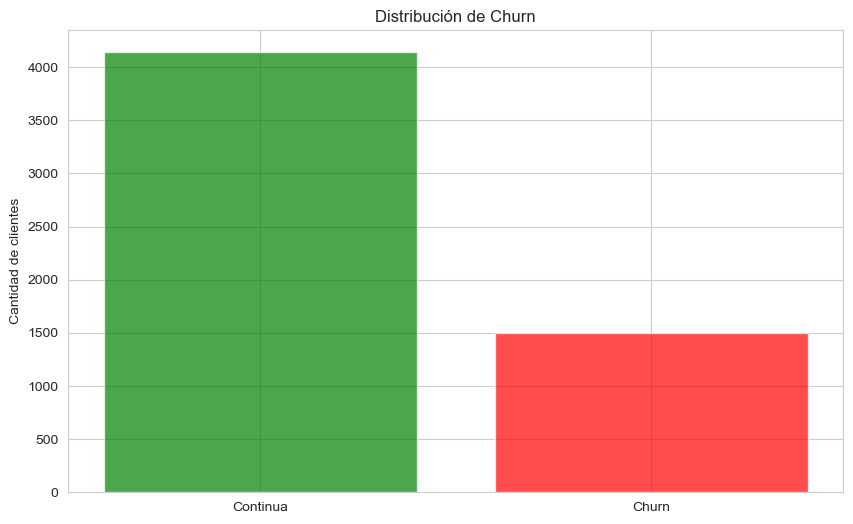

In [4]:
#Chequeo si está balanceada la variable objetivo 'Churn'
colors = ['green','red']
labels = ['Continua','Churn']

# Calculamos la distribución de la variable objetivo 'Churn' 
churn_continua_train = train_df['Churn'].value_counts()
porcentajes = churn_continua_train / len(train_df) * 100

print(f"\nLa clase minoritaria representa el {porcentajes.min():.2f}% del dataset de entrenamiento.")

def evaluar_balance(porcentaje: float) -> None:
    if porcentaje >= 40:
        print("La variable objetivo no está desbalanceada.")
    elif 20 <= porcentaje < 40:
        print("La variable objetivo está moderadamente desbalanceada.")
    elif 1 <= porcentaje < 20:
        print("La variable objetivo está fuertemente desbalanceada.")
    elif porcentaje < 1:
        print("La variable objetivo está extremadamente desbalanceada.")

# Vemos cuan desbalanceada está la variable objetivo
evaluar_balance(porcentajes.min())

plt.bar(churn_continua_train.index, churn_continua_train.values, color=colors, alpha=0.7)

plt.xticks(churn_continua_train.index, labels)
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de Churn")
plt.show()

Se ve un claro desbalanceo el cual será tratado en el preprocesamiento de datos

### Análisis de la distribución de las variables numéricas

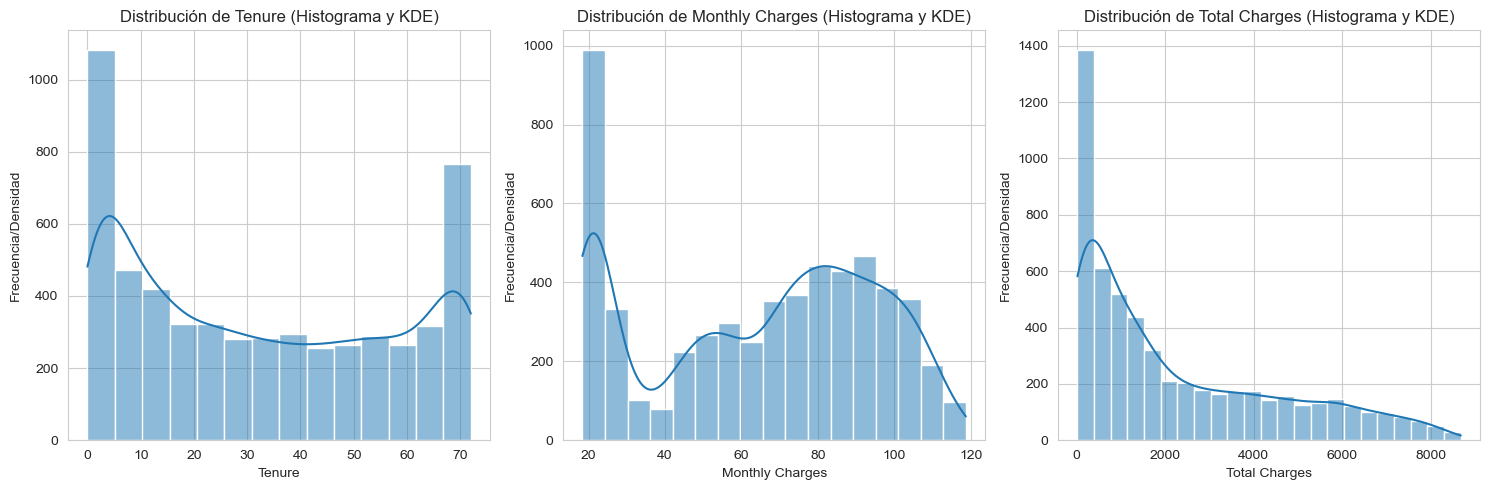

In [5]:
plt.figure(figsize=(15, 5))

# Subplot 1
# Tenure = Tenencia del cliente con la empresa = tiempo que lleva siendo cliente
plt.subplot(1, 3, 1)
sns.histplot(data=train_df, x='tenure', kde=True)
plt.title('Distribución de Tenure (Histograma y KDE)')
plt.xlabel('Tenure')
plt.ylabel('Frecuencia/Densidad')

# Subplot 2
plt.subplot(1, 3, 2)
sns.histplot(data=train_df, x='MonthlyCharges', kde=True)
plt.title('Distribución de Monthly Charges (Histograma y KDE)')
plt.xlabel('Monthly Charges')
plt.ylabel('Frecuencia/Densidad')

# Subplot 3
plt.subplot(1, 3, 3)
sns.histplot(data=train_df, x='TotalCharges', kde=True)
plt.title('Distribución de Total Charges (Histograma y KDE)')
plt.xlabel('Total Charges')
plt.ylabel('Frecuencia/Densidad')

plt.tight_layout()
plt.show()


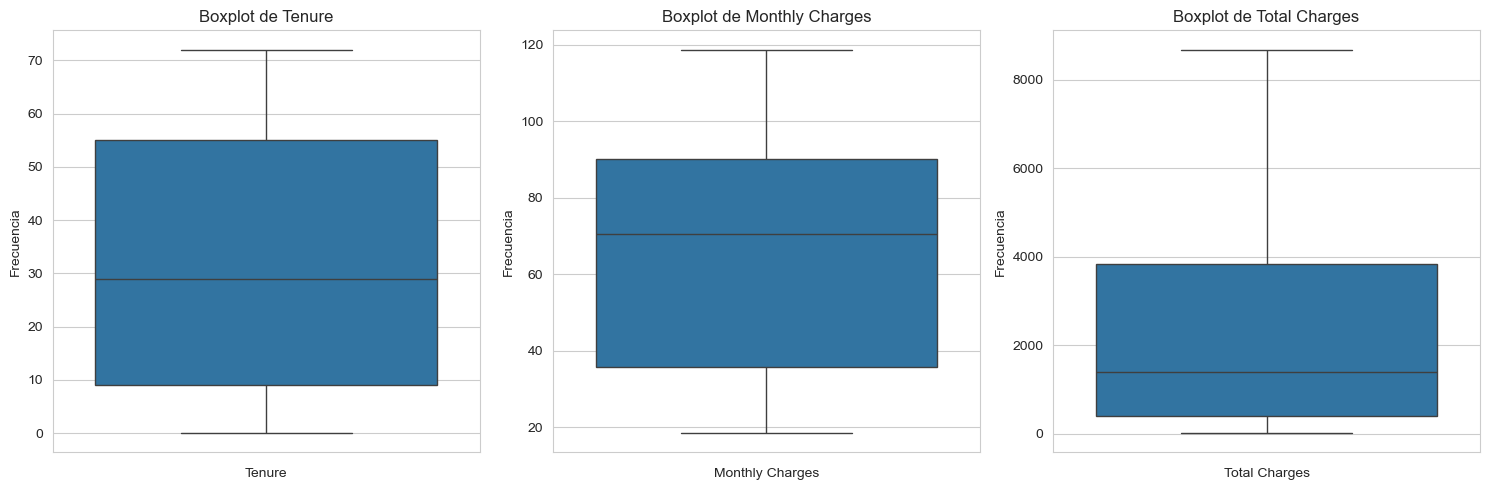

In [6]:
plt.figure(figsize=(15, 5))

# Subplot 1
plt.subplot(1, 3, 1)
sns.boxplot(y=train_df['tenure'])
plt.title('Boxplot de Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frecuencia')

# Subplot 2
plt.subplot(1, 3, 2)
sns.boxplot(y=train_df['MonthlyCharges'])
plt.title('Boxplot de Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frecuencia')

# Subplot 3
plt.subplot(1, 3, 3)
sns.boxplot(y=train_df['TotalCharges'])
plt.title('Boxplot de Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


No se presentan outliers en las variables numéricas

### Análisis previo a tratamiento de las variables objeto/categóricas

In [7]:
# Función creada para ver las distintas categorías que componen las columnas/variables tipo objeto. En caso de que el número de categorías sea elevado
# se deberá realizar un procesamiento distinto al OneHotEncoder (se tendría una cantidad de columnas excesiva).
# Además se puede apreciar qué categorías tiene cada columna y entenderla mejor.
def categorias_columnas_objeto(df,max_categorias=5):
    # Diccionario para guardar categorías
    categorical_dict = {}

    for col in df.select_dtypes(include=['object', 'category']).columns:
        unique_vals = df[col].unique()
        #Se indica una advertencia en caso de que la cantidad de categorías sea excesiva (se consideró más de 5)
        if len(unique_vals) > max_categorias:
            advertencia = f"Más de {max_categorias} categorías ({len(unique_vals)}). No se incluirá."
            categorical_dict[col] = [advertencia]
            
        else:
            categorical_dict[col] = list(unique_vals)

    # Convertir diccionario en DataFrame
    # Se usa pd.DataFrame.from_dict con orient='index' y luego se transpone
    categorical_df = pd.DataFrame.from_dict(categorical_dict, orient='index').transpose()

    # Visualizar
    return categorical_df

categorias = categorias_columnas_objeto(train_df, max_categorias=5)
categorias

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Más de 5 categorías (5634). No se incluirá.,Male,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,No
1,None,Female,Yes,Yes,Yes,No,Fiber optic,Yes,Yes,No,Yes,No,No,Two year,Yes,Mailed check,Yes
2,None,None,None,None,None,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,None,Credit card (automatic),None
3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Bank transfer (automatic),None


Se ve que aprecia que vamos a tener columnas redundantes al realizar el onehot-encoder (las que indican que no se contaba con servicio de internet)

# **3. Preprocesamiento de Datos**

Prepararemos los datos para que puedan ser utilizados por los modelos de Machine Learning.

### a) Primero transformamos todas las columnas con datos categóricos a binario para poder ser alimentadas posteriormente a nuestro modelo

In [8]:
# Crear copias de los DataFrames originales para preservar los datos sin modificaciones
train_df1 = train_df.copy()
test_df1 = test_df.copy()

#Remoción de la columna 'customerID' (no aporta valor predictivo)
train_df1.drop(columns=['customerID'], inplace=True)
test_df1.drop(columns=['customerID'], inplace=True) 

# Identificar columnas categóricas y numéricas
categorical_cols = train_df1.select_dtypes(include=['object', 'category']).columns
numeric_cols = train_df1.select_dtypes(include=['int64', 'float64']).columns


# Crear encoder
ohe = OneHotEncoder(drop='if_binary',handle_unknown='ignore', sparse_output=False)

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, categorical_cols),   # aplica OHE solo a categóricas
        ('num', 'passthrough', numeric_cols)  # deja numéricas igual
    ]
)


# Ajustar con train y transformar ambos
train_encoded = preprocessor.fit_transform(train_df1)

# Convertir a DataFrame con nombres de columnas
train_encoded_df2 = pd.DataFrame(train_encoded, 
                                columns=preprocessor.get_feature_names_out(train_df1.columns),
                                index=train_df1.index)

print(train_encoded_df2.shape)
print(train_encoded_df2.columns)


# Identifico todas las columnas que continen "No internet service"
cols_to_drop = [col for col in train_encoded_df2.columns 
                if "No" in col and col != "cat__InternetService_No"
]

train_encoded_df3 = train_encoded_df2.copy()
# Elimino esas columnas junto con la columna de "No phone service"
train_encoded_df3.drop(columns=cols_to_drop, inplace=True)

#Estandarizo las columnas numéricas
train_encoded_df4 = train_encoded_df3.copy()

# Visualización de primeras filas para ver el resultado final del OneHot-Encoder
train_encoded_df4.head(10)

(5634, 41)
Index(['cat__gender_Male', 'cat__Partner_Yes', 'cat__Dependents_Yes',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service', 'cat__OnlineSecurity_Yes',
       'cat__OnlineBackup_No', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes', 'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__StreamingTV_Yes', 'cat__StreamingMovies_No',
       'cat__StreamingMovies_No internet service', 'cat__StreamingMovies_Yes',
       'cat__Contract_Month-to-month', 'cat__Contract_One yea

,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,cat__OnlineBackup_Yes,...,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__Churn_Yes,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,35.0,49.20,1701.65
1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15.0,75.10,1151.55
2,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,40.55,590.35
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,26.0,73.50,1905.70
4,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,44.55,44.55
5,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,66.0,79.50,5196.10
6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,19.80,19.80
7,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,40.0,56.60,2379.10
8,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,65.0,59.80,3808.20
9,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0,80.55,4847.05


Realizamos unos heatmaps comparativos para justificar la remoción de las columnas redundantes y ver la correlación entre las distintas variables

cat__Churn_Yes                         1.000
cat__Contract_Month-to-month           0.406
cat__InternetService_Fiber optic       0.313
cat__PaymentMethod_Electronic check    0.309
cat__Contract_Two year                -0.302
num__tenure                           -0.346
Name: cat__Churn_Yes, dtype: float64


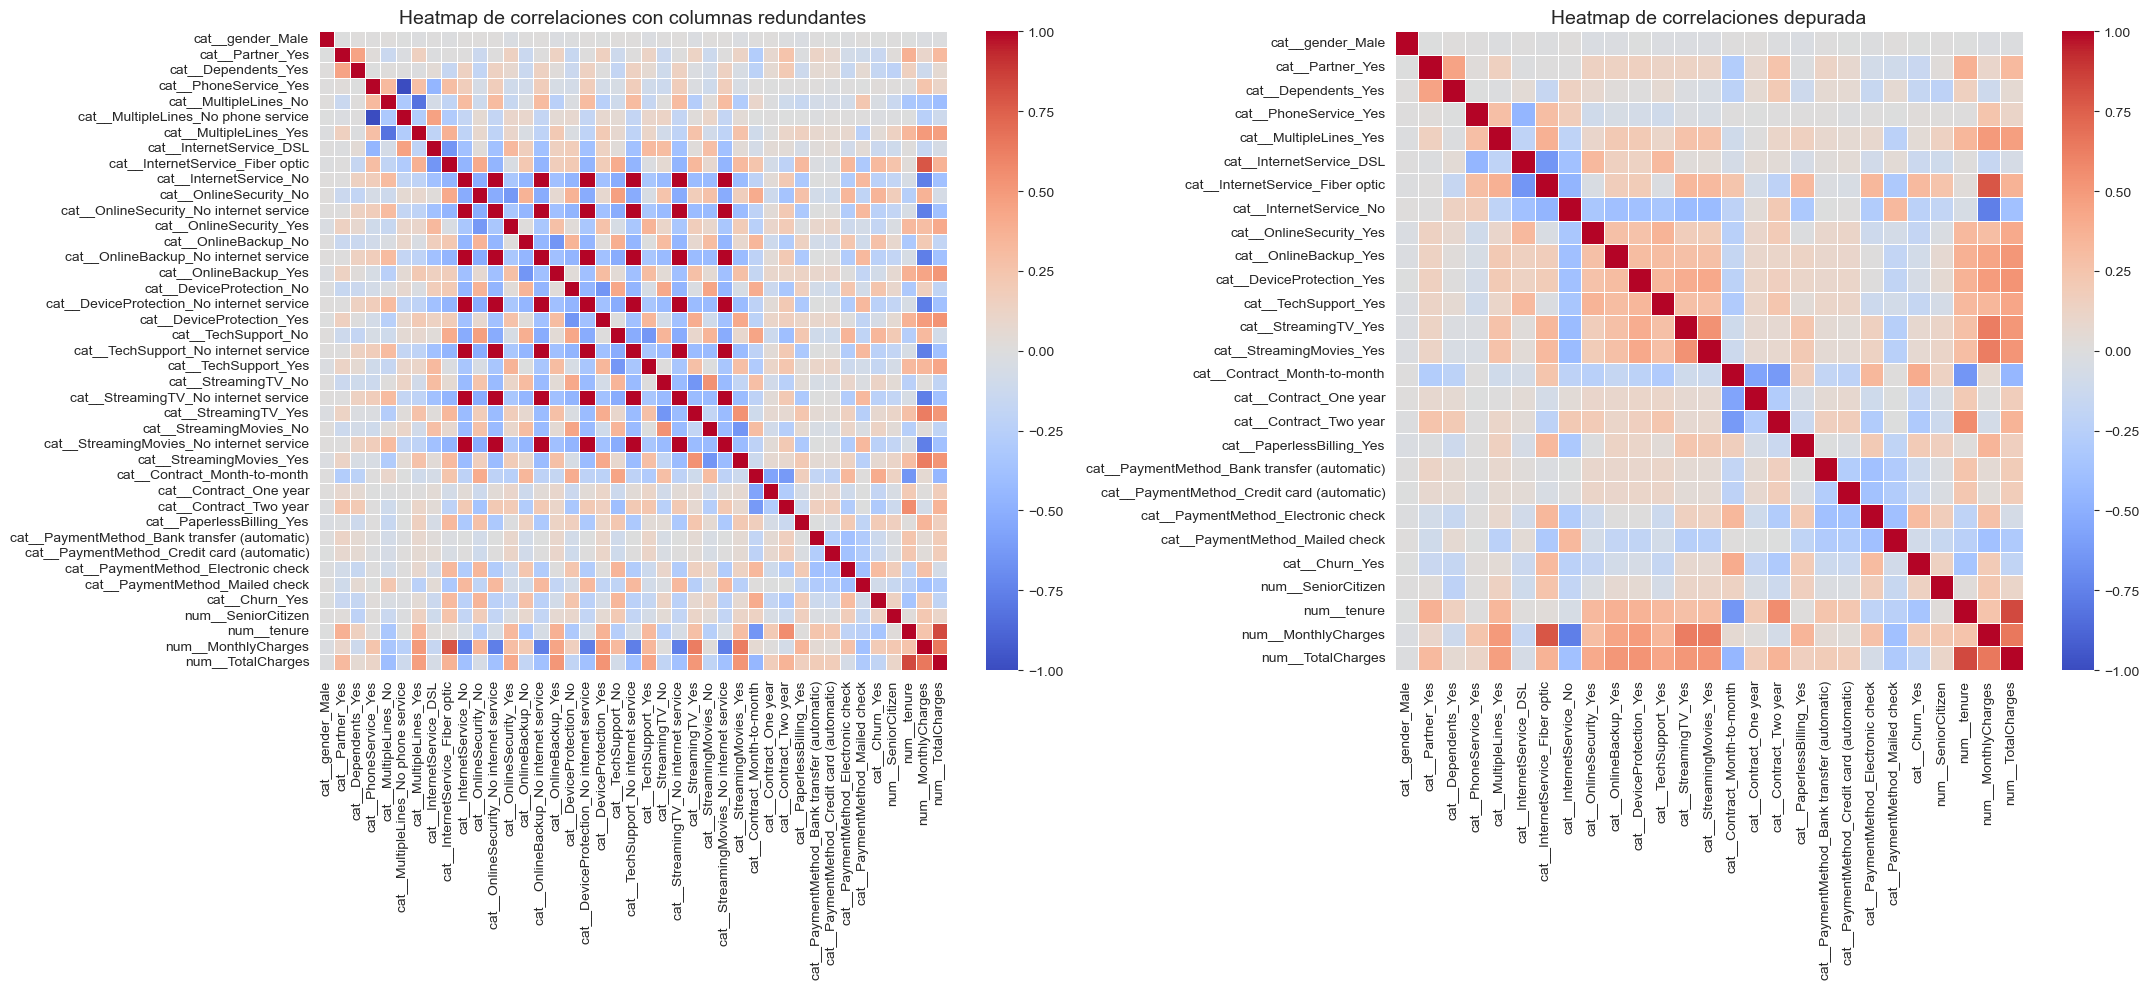

In [9]:
corr_matrix_df2 = train_encoded_df2.corr().round(3)
corr_matrix_df3 = train_encoded_df3.corr().round(3)

corr_churn_df3 = corr_matrix_df3['cat__Churn_Yes']
print(corr_churn_df3.sort_values(ascending=False)[abs(corr_churn_df3) > 0.3])

# Configurar tamaño de la figura
plt.figure(figsize=(22,10))
plt.subplot(1, 2, 1)
# Crear heatmap
sns.heatmap(corr_matrix_df2, cmap="coolwarm", annot=False, linewidths=0.5)
# Título
plt.title("Heatmap de correlaciones con columnas redundantes", fontsize=14)

plt.subplot(1, 2, 2)
sns.heatmap(corr_matrix_df3, vmax=1, vmin=-1, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Heatmap de correlaciones depurada", fontsize=14)

plt.tight_layout()
plt.show()

Generamos una nuevas features con posibilidades de aumentar la eficacia del modelo y estandarizamos.

In [ ]:
# Copia del DataFrame original
train_encoded_df4 = train_encoded_df3.copy()
# Variable que combina el coste del servicio con la antigüedad del cliente. La lógica detrás de esta variable es que los clientes con mayor antigüedad
# tendrán una mayor resiliencia a costos de servicio elevado y lo opuesto para los clientes de menor antigüedad.
train_encoded_df4['NEW_MonthlyCharges_Tenure'] = (train_encoded_df4['num__MonthlyCharges'] / train_encoded_df4['num__tenure'].replace(0, 1))

# Variable que crea un "nivel de servicio del cliente" al combinar todos los los servicios de internet con el tipo de internet que tiene el cliente 
# Se le asigna un peso determinado tanto al tipo de internet como al servicio en función de la correlación final que tiene la nueva feature con la feature objetivo churn
def calcular_nivel(df, k_dsl, k_fiber, a,b,c,d,e,f):
    internet_factor = df['cat__InternetService_DSL']*k_dsl+df['cat__InternetService_Fiber optic']*k_fiber
    servicios = (a*df['cat__OnlineSecurity_Yes'] + 
                 b*df['cat__OnlineBackup_Yes'] + 
                 c*df['cat__DeviceProtection_Yes'] + 
                 d*df['cat__TechSupport_Yes'] + 
                 e*df['cat__StreamingTV_Yes'] + 
                 f*df['cat__StreamingMovies_Yes'])
    return internet_factor * servicios

"""
# Debido a los tiempos que toma la iteración para la obtención de los mejores factores se decidió correr una vez e introducir los factores
# manualmente en la variable "mejores constantes"
mejor_corr = -1
mejores_constantes = None

# Definir rangos de búsqueda
k_dsl_vals =  (1,1.5,2)
k_fiber_vals = (1,1.5,2,2.5)
coef_vals = (-2,-1.5,-0.5,0.5,1.5,2)

for k_dsl, k_fiber, a,b,c,d,e,f in product(k_dsl_vals, k_fiber_vals, coef_vals, coef_vals, coef_vals, coef_vals, coef_vals, coef_vals):
    nivel = calcular_nivel(train_encoded_df4, k_dsl, k_fiber, a,b,c,d,e,f)
    corr = np.corrcoef(nivel, train_encoded_df4['cat__Churn_Yes'])[0,1]
    if abs(corr) > mejor_corr:
        mejor_corr = abs(corr)
        mejores_constantes = (k_dsl, k_fiber, a,b,c,d,e,f)

print("Mejor correlación:", mejor_corr)
print("Constantes óptimas:", mejores_constantes)

"""
# Se aceptan aportes negativos en la función "nivel de internet" dado que hay variables que se correlacionan positiva y negativamente con la variable "cat_Churn_Yes"
mejor_corr = 0.267
mejores_constantes = (1.5, 2, -2, -0.5, -0.5, -2, 1.5, 1.5)


train_encoded_df4['Nivel_de_Servicio'] = calcular_nivel(train_encoded_df4,*mejores_constantes)


# Al estandarizar se busco hacer dicho proceso solo con las columnas numéricas no binarias
# 1. Detectar columnas binarias
binary_cols = [col for col in train_encoded_df4.columns 
               if train_encoded_df4[col].dropna().nunique() == 2]

# 2. Seleccionar columnas numéricas no binarias
numeric_cols = train_encoded_df4.select_dtypes(include=['float64','int']).drop(columns=binary_cols)

# 3. Escalar solo las numéricas no binarias
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(numeric_cols)

# 4. Reconstruir DataFrame
train_scaled_df4 = pd.DataFrame(
    scaled_numeric,
    columns=numeric_cols.columns,
    index=train_encoded_df4.index
)

# 5. Agregar columnas binarias sin modificar
train_scaled_df4 = pd.concat([train_scaled_df4, train_encoded_df4[binary_cols]], axis=1)

# 6. Mantener el orden original
train_scaled_df4 = train_scaled_df4[train_encoded_df4.columns]

# Vemos una descripción de la nueva columna creada
print(train_scaled_df4['NEW_MonthlyCharges_Tenure'].describe())


# Ver primeras filas
train_scaled_df4.head(10)




count    5.634000e+03
mean    -1.765637e-17
std      1.000089e+00
min     -5.090120e-01
25%     -4.471266e-01
50%     -3.945847e-01
75%     -1.265832e-01
max      5.665314e+00
Name: NEW_MonthlyCharges_Tenure, dtype: float64


,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,cat__OnlineBackup_Yes,...,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__Churn_Yes,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,NEW_MonthlyCharges_Tenure,Nivel_de_Servicio
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.102371,-0.521976,-0.263289,-0.439590,1.433743
1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,-0.711743,0.337478,-0.504814,-0.219852,-1.196244
2,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,-0.793155,-0.809013,-0.751213,-0.335028,-2.129465
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,-0.263980,0.284384,-0.173699,-0.352865,1.179228
4,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,-1.281624,-0.676279,-0.990851,2.193161,0.161169
5,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.364249,0.483485,1.270975,-0.451866,0.161169
6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,-1.281624,-1.497571,-1.001718,0.682867,0.161169
7,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.305900,-0.276418,0.034150,-0.439023,-0.093346
8,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.323543,-0.170230,0.661607,-0.469229,-0.093346
9,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.120015,0.518328,1.117722,-0.443447,0.415683


cat__Churn_Yes                                  1.000
cat__Contract_Month-to-month                    0.406
NEW_MonthlyCharges_Tenure                       0.375
cat__InternetService_Fiber optic                0.313
cat__PaymentMethod_Electronic check             0.309
Nivel_de_Servicio                               0.267
num__MonthlyCharges                             0.198
cat__PaperlessBilling_Yes                       0.198
num__SeniorCitizen                              0.146
cat__PaymentMethod_Bank transfer (automatic)   -0.125
cat__InternetService_DSL                       -0.129
cat__PaymentMethod_Credit card (automatic)     -0.138
cat__Partner_Yes                               -0.146
cat__TechSupport_Yes                           -0.166
cat__Dependents_Yes                            -0.167
cat__OnlineSecurity_Yes                        -0.175
cat__Contract_One year                         -0.179
num__TotalCharges                              -0.194
cat__InternetService_No     

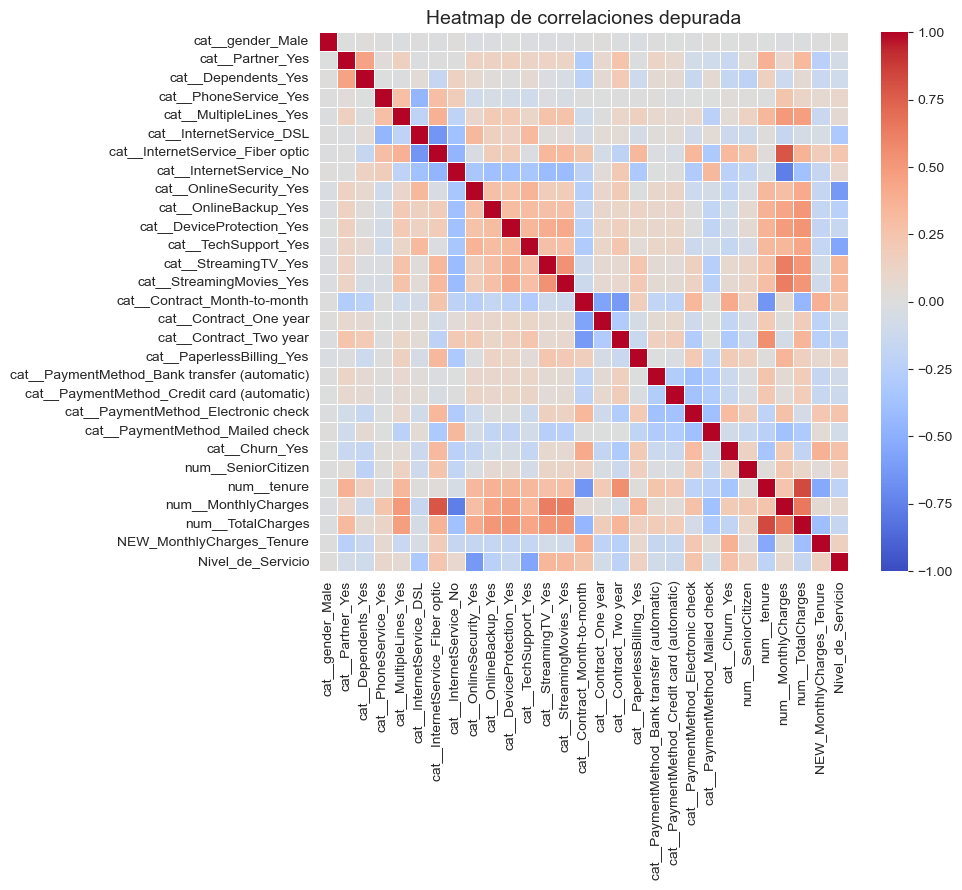

In [11]:
# Analisamos la correlación de las features con la variable objetivo 'Churn'
corr_matrix_df4 = train_scaled_df4.corr()

corr_churn_df4 = corr_matrix_df4['cat__Churn_Yes'].round(3)
print(corr_churn_df4.sort_values(ascending=False)[abs(corr_churn_df4) > 0.1])

#Para verificar como se ve afectado el entrenamiento del modelo con las distintas Features
corr_churn_df5 = corr_churn_df4.abs().sort_values(ascending=False)
#Seleccionar las 15 features más correlacionadas (se eligieron 15 dado que así se contempla la feature cat__TechSupport_Yes)
top_features = corr_churn_df5.index[:6].drop(['cat__Churn_Yes']) #Se remueve la variable objetivo y la nueva feature creada (combinación de MonthlyCharges y Tenure)
print(top_features)

# Configurar tamaño de la figura
plt.figure(figsize=(10,9))

sns.heatmap(corr_matrix_df4, vmax=1, vmin=-1, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Heatmap de correlaciones depurada", fontsize=14)

plt.tight_layout()
plt.show()

Vistas las correlaciones entre variables nos disponemos a realizar un pairplot para ver la relación y la distribución entre la variable objetivo y las variables más pertinentes para una posible inferencia.

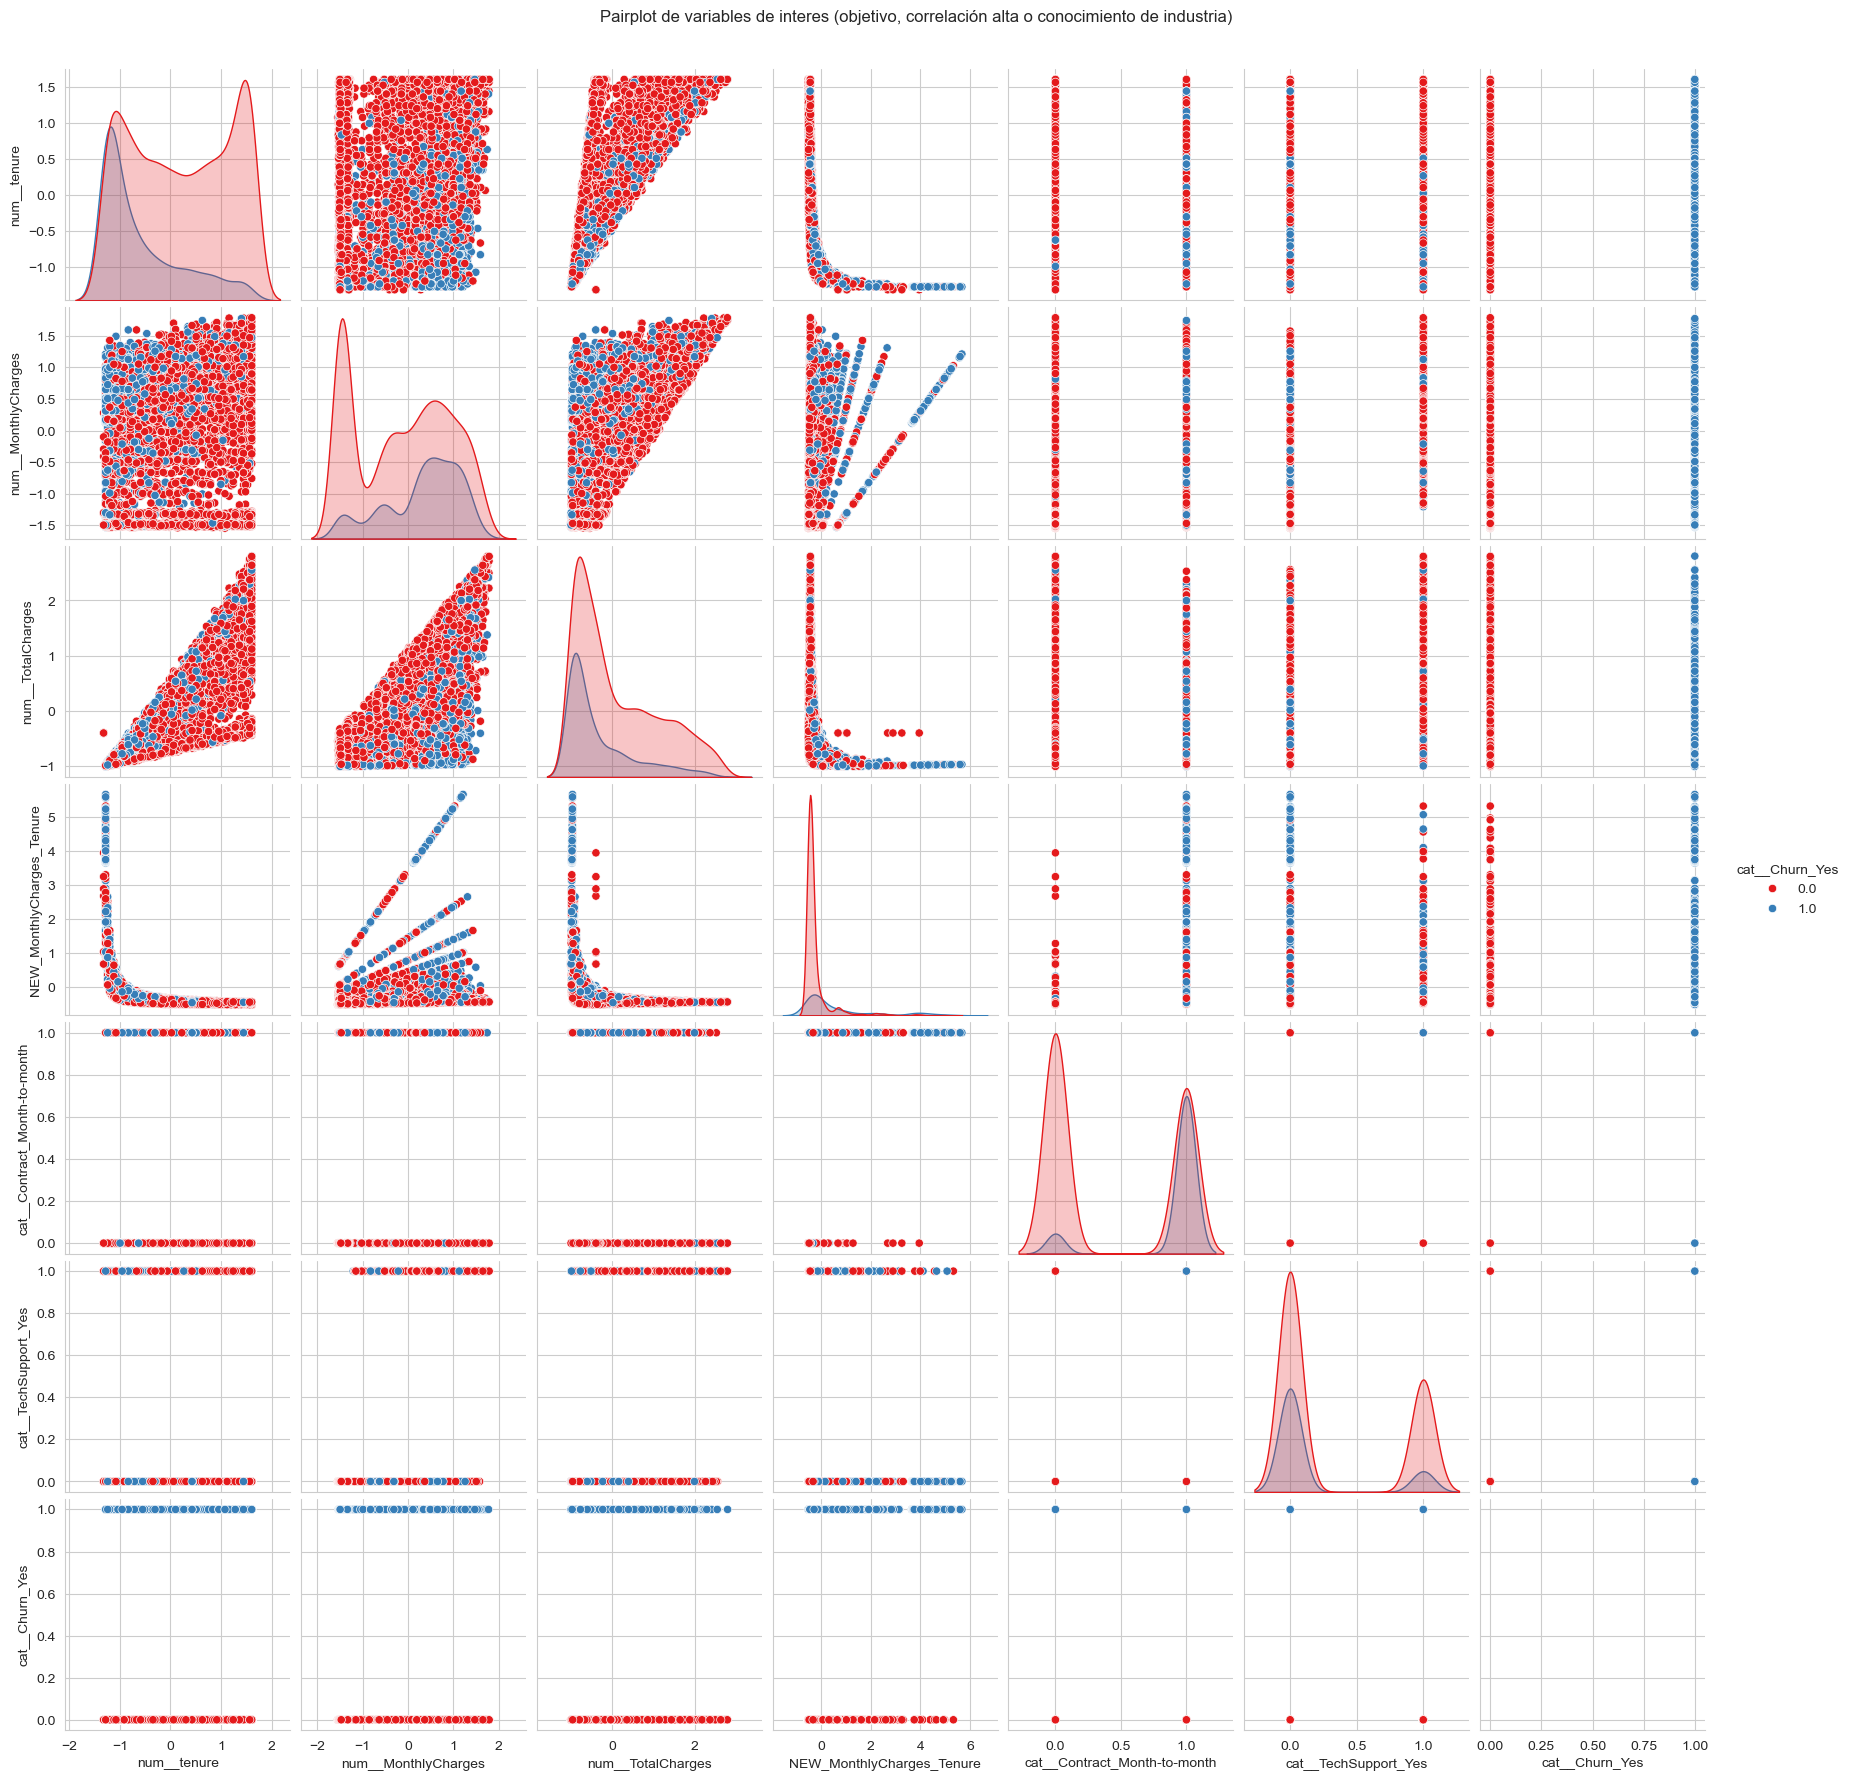

In [12]:
sns.pairplot(data=train_scaled_df4, vars=['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'NEW_MonthlyCharges_Tenure', 'cat__Contract_Month-to-month', 'cat__TechSupport_Yes', 'cat__Churn_Yes'],
             hue='cat__Churn_Yes', diag_kind='kde', palette='Set1')
plt.suptitle("Pairplot de variables de interes (objetivo, correlación alta o conocimiento de industria)", y=1.02)
plt.show()

# **4. Modelado y Evaluación**

## Ahora entrenaremos y evaluaremos los tres modelos requeridos:
## Regresión Logística, k-NN y Naive Bayes.


Definimos la función a utilizar para particionar los datos. En principio los dataset *Todo* y *NEW* son iguales para todos los modelos pero las *Features_destiladas* y *Features_destiladas_con_nueva* son ajustadas para cada modelo en cuestión.

In [13]:
target_names = train_scaled_df4['cat__Churn_Yes'].map({0: 'Continua', 1: 'Churn'}).unique()

def preparar_datos_modelado(train_scaled_df4,features_mejoran_recall):
    """Prepara los datos para el modelado dividiéndolos en conjuntos de entrenamiento y prueba,
    y aplicando SMOTE para manejar el desbalanceo de clases.
    Retorna diccionarios con los conjuntos de datos originales y los conjuntos balanceados con SMOTE.
    
    train_scaled_df4: DataFrame preprocesado con features estandarizadas y codificadas.
    features_mejoran_recall: Lista de nombres de columnas que mejoran el recall del modelo.
    """
   
    features_destiladas = features_mejoran_recall.copy()


    # Condicional: si alguna de las columnas está en la lista
    if any(col in features_mejoran_recall for col in ['NEW_MonthlyCharges_Tenure', 'num__tenure', 'num__MonthlyCharges']):
        # Features_destiladas → sin NEW_MonthlyCharges_Tenure
        features_destiladas = [col for col in features_mejoran_recall if col != ['NEW_MonthlyCharges_Tenure', 'Nivel_de_Servicio']]
        
        # Features_destiladas_con_nueva → reemplazo: uso NEW_MonthlyCharges_Tenure y quito tenure y MonthlyCharges y lo analogo con las variables que componen Nivel_de_Servicio (las de mayor correlación con la variable Churn)
        features_destiladas_con_nueva = [col for col in features_mejoran_recall if col not in ['num__tenure', 'num__MonthlyCharges','cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_Yes']]
        # Aseguro que NEW_MonthlyCharges_Tenure esté presente
        if 'NEW_MonthlyCharges_Tenure' not in features_destiladas_con_nueva:
            features_destiladas_con_nueva.append('NEW_MonthlyCharges_Tenure')

    else:
        # Si no están esas columnas, uso la lista original
        features_destiladas = features_mejoran_recall
        features_destiladas_con_nueva = features_mejoran_recall

    features = {
    'Todo': train_scaled_df4.drop(columns=['cat__Churn_Yes' , 'NEW_MonthlyCharges_Tenure', 'Nivel_de_Servicio']),
    'NEW': train_scaled_df4[['NEW_MonthlyCharges_Tenure', 'Nivel_de_Servicio']],
    'Features_destiladas': train_scaled_df4[features_destiladas],
    'Features_destiladas_con_nueva': train_scaled_df4[features_destiladas_con_nueva],
    }
   
    y = train_scaled_df4['cat__Churn_Yes']
    datasets = {}
    SMOTEdatasets = {}

    smote = SMOTE(random_state=42)

    for key, X in features.items():
        # Split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

        datasets[key] = (X_train, X_test, y_train, y_test)
        
        # SMOTE solo sobre train
        X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

        SMOTEdatasets[key] = (X_resampled, X_test, y_resampled, y_test)

    return datasets, SMOTEdatasets, features

In [14]:
# Función para ahorrar líneas de código
def reporte_modelo(model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None):
    """Genera un reporte de evaluación del modelo incluyendo accuracy, precision, Recall, F1-score y matriz de confusión.
    model: Modelo entrenado.
    X_train: Conjunto de características de entrenamiento.
    y_train: Conjunto de etiquetas verdaderas del conjunto de entrenamiento.
    X_test: Conjunto de características de prueba.
    y_test: Conjunto de etiquetas verdaderas del conjunto.
    feature: Nombre del conjunto de características utilizado.
    target_names: Nombres de las clases objetivo.
    """
        
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)


    for clase in target_names:
        resultados.append({
            "Dataset": contador,
            "Clase": clase,
            "Features": feature,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
        })

    return resultados


## Modelo KNN
### Sin datos balanceados

Como se mencionó previamente primero se realiza una iteración alimentando el modelo con distintas features las cuales, iterando exhaustivamente, se busca el conjunto de variables que brinden el mayor F1-score y recall de la variable de menor representación ("ocurre churn") dado que el recall es el mayor problema como se verá más adelante. Se selecciona el mejor conjunto de variables para alimentar el modelo en el entrenamiento real (las features destiladas).
Adelantandome a los resultados, el tiempo computacional que insumió buscar dichas variables finamente seleccionadas no valió la pena, en particular para el modelo KNN que tardó aproximadamente 40 minutos en iterar tanto para el modelo con y sin SMOTE aplicado. Se facilitan los resultados para no tener que recurrir a dicha operación.

In [ ]:
resultados = []
k_values = range(1, 20, 2) # Probar k de 1 a 11 (impares)

KNN = KNeighborsClassifier()

X = train_scaled_df4[top_features] #Las columnas de las features que más correlación tienen con la variable objetivo

for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):
    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista
        accuracies_cv = []
        for k_val in k_values:
            scores = cross_val_score(KNN, train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], cv=5, scoring='accuracy')
            accuracies_cv.append(scores.mean()) # Guardar la media de las puntuaciones de CV


        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)
        # Ahora comparas las accuracies_cv para encontrar el mejor k
        best_k_cv = k_values[np.argmax(accuracies_cv)]

        KNN = KNeighborsClassifier(n_neighbors=best_k_cv)
        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(KNN,X_train, y_train, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfKNN = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfKNN[scores_dfKNN["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalKNN = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresKNN = best_globalKNN["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalKNN['Features']}")
print(f"F1-score: {best_globalKNN['F1-score']:.3f} | Recall: {best_globalKNN['Recall']:.3f} | Accuracy: {best_globalKNN['Accuracy']:.3f}")



🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['cat__Contract_Month-to-month', 'cat__InternetService_Fiber optic'] | F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776
- 3 features: ['cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.592 | Recall: 0.718 | Accuracy: 0.751
- 4 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.505 | Recall: 0.527 | Accuracy: 0.740
- 5 features: ['NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__PaymentMethod_Electronic check', 'cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month'] | F1-score: 0.508 | Recall: 0.541 | Accuracy: 0.736

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month', 'cat__PaymentMethod_Electronic check']
F1-score: 0.592 | Recall: 0.718 | Acc

Entrenamiento con el conjunto de features *"Todo"*, *"NEW"*, *features_destiladas* y *"features seleccionadas+NEW"*

Subset 'Todo' → Mejor k: 17 | F1 promedio: 0.595


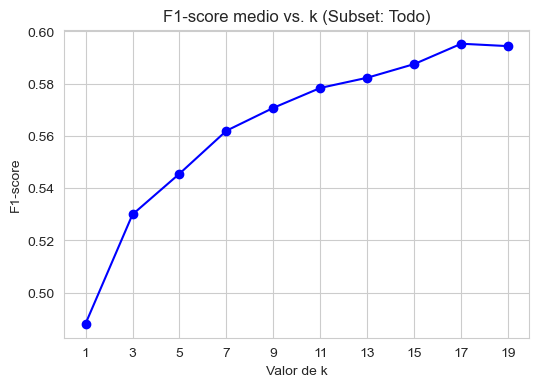

Subset 'NEW' → Mejor k: 17 | F1 promedio: 0.525


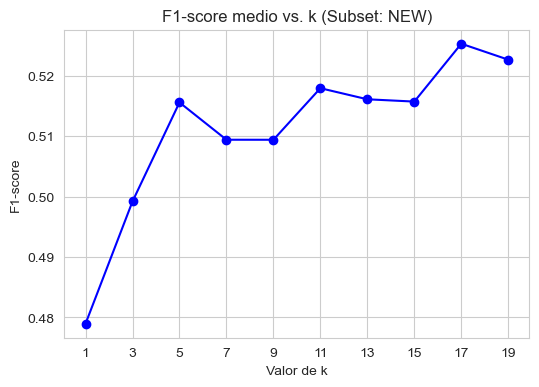

Subset 'Features_destiladas' → Mejor k: 7 | F1 promedio: 0.503


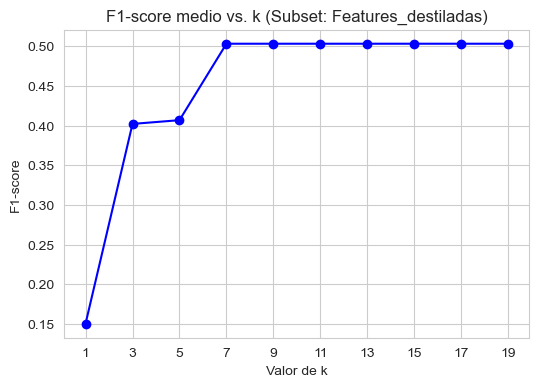

Subset 'Features_destiladas_con_nueva' → Mejor k: 7 | F1 promedio: 0.503


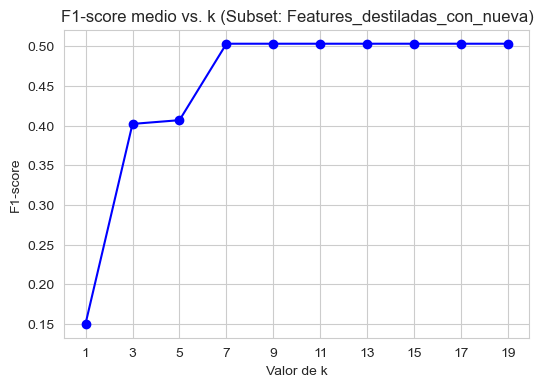

['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos desbalanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.772      0.833   0.862   
1                           Todo     Churn     0.772      0.578   0.521   
2                            NEW  Continua     0.772      0.812   0.896   
3                            NEW     Churn     0.772      0.598   0.428   
4            Features_destiladas  Continua     0.778      0.815   0.903   
5            Features_destiladas     Churn     0.778      0.616   0.432   
6  Features_destiladas_con_nueva  Continua     0.778      0.815   0.903   
7  Features_destiladas_con_nueva     Churn     0.778      0.616   0.432   

   F1-score Modelo  
0     0.847    KNN  
1     0.548    KNN  
2     0.852    KNN  
3     0.499    KNN  
4     0.856    KNN  
5     0.508    KNN  
6     0.856    KNN  
7     0.508    KNN  


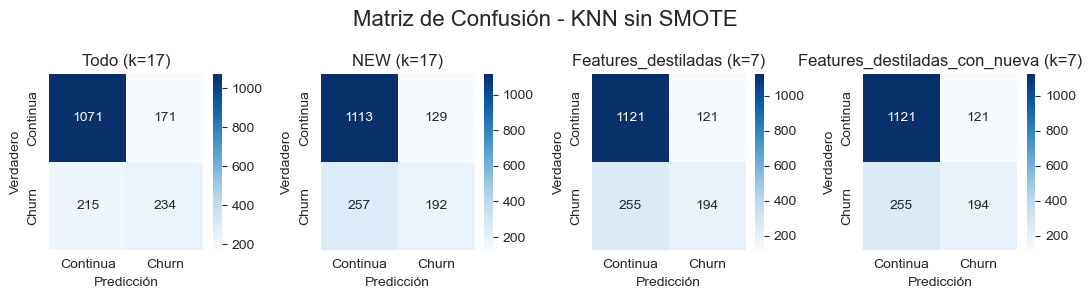

In [42]:
k_values = range(1, 20, 2) # Probar k de 1 a 11 (impares)

best_k_por_subset = {}
scores_por_subset = {}

datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresKNN)
#Busco el mejor k con validación cruzada

for nombre, X in features.items():
    accuracies_cv = []
    for k_val in k_values:
        scores = cross_val_score(KNeighborsClassifier(n_neighbors=k_val), X, train_scaled_df4['cat__Churn_Yes'], cv=5, scoring='f1')
        # guardar el mejor k por subset
        accuracies_cv.append(scores.mean()) # Guardar la media de las puntuaciones de CV

    # Guardar resultados
    scores_por_subset[nombre] = accuracies_cv
    best_k_cv = k_values[np.argmax(accuracies_cv)]
    best_k_por_subset[nombre] = best_k_cv
    
    print(f"Subset '{nombre}' → Mejor k: {best_k_cv} | F1 promedio: {max(accuracies_cv):.3f}")

    # Graficar resultados de este subset
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, accuracies_cv, marker='o', linestyle='-', color='b')
    plt.title(f'F1-score medio vs. k (Subset: {nombre})')
    plt.xlabel('Valor de k')
    plt.ylabel('F1-score')
    plt.xticks(k_values)
    plt.grid(True)
    plt.show()


KNN = KNeighborsClassifier(n_neighbors=best_k_cv)

nombres_df = list(features.keys())
titulos = ['Modelo'] + nombres_df
resultados = []
roc_auc_KNN = ['KNN']
fpr_KNN = []
tpr_KNN = []
thresholds_KNN = []

for set_dato, (X_train, X_test, y_train, y_test) in datasets.items():
    KNN.fit(X_train, y_train)
    y_pred = KNN.predict(X_test)
    y_score = KNN.predict_proba(X_test)[:,1]

    roc_auc_KNN.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_KNN.append(fpr)
    tpr_KNN.append(tpr)
    thresholds_KNN.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosKNN = pd.DataFrame(resultados).round(3)
df_resultadosKNN['Modelo'] = 'KNN'


print("Datos desbalanceados:\n")
print(df_resultadosKNN.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosKNN['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosKNN[df_resultadosKNN['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre} (k={best_k_por_subset[nombre]})')

plt.suptitle('Matriz de Confusión - KNN sin SMOTE', fontsize=16)
plt.tight_layout()
plt.show()


Las variables destiladas con y sin variables resultaron ser las mismas.

Se repite el proceso pero aplicando SMOTE a los dataframes de train.

### Con datos balanceados (SMOTE)

In [43]:
resultados = []
k_values = range(1, 20, 2) # Probar k de 1 a 11 (impares)

KNN = KNeighborsClassifier()
smote = SMOTE(random_state=42)

X = train_scaled_df4[top_features]


for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):
    prev_accuracy = None
    prev_recall_churn = None
    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista
        accuracies_cv = []
        for k_val in k_values:
            scores = cross_val_score(KNN, train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], cv=5, scoring='accuracy')
            accuracies_cv.append(scores.mean()) # Guardar la media de las puntuaciones de CV


        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)
        # Ahora comparas las accuracies_cv para encontrar el mejor k
        best_k_cv = k_values[np.argmax(accuracies_cv)]

        X_trainSMOTE, y_trainSMOTE = smote.fit_resample(X_train, y_train)

        KNN = KNeighborsClassifier(n_neighbors=best_k_cv)
        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(KNN,X_trainSMOTE, y_trainSMOTE, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfKNNSMOTE = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfKNNSMOTE[scores_dfKNN["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalKNNSMOTE = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresKNNSMOTE = best_globalKNN["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalKNNSMOTE['Features']}")
print(f"F1-score: {best_globalKNNSMOTE['F1-score']:.3f} | Recall: {best_globalKNNSMOTE['Recall']:.3f} | Accuracy: {best_globalKNNSMOTE['Accuracy']:.3f}")


🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['cat__Contract_Month-to-month', 'cat__InternetService_Fiber optic'] | F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776
- 3 features: ['cat__Contract_Month-to-month', 'cat__InternetService_Fiber optic', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.579 | Recall: 0.746 | Accuracy: 0.727
- 4 features: ['NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month'] | F1-score: 0.524 | Recall: 0.605 | Accuracy: 0.724
- 5 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__PaymentMethod_Electronic check', 'cat__InternetService_Fiber optic'] | F1-score: 0.517 | Recall: 0.595 | Accuracy: 0.720

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__Contract_Month-to-month', 'cat__InternetService_Fiber optic']
F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776


Subset 'Todo' → Mejor k: 1 | F1 promedio: 0.856


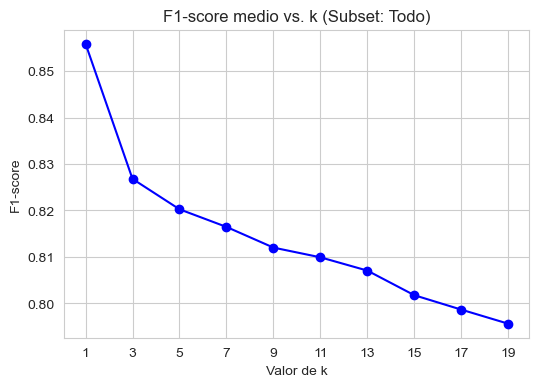

Subset 'NEW' → Mejor k: 1 | F1 promedio: 0.856


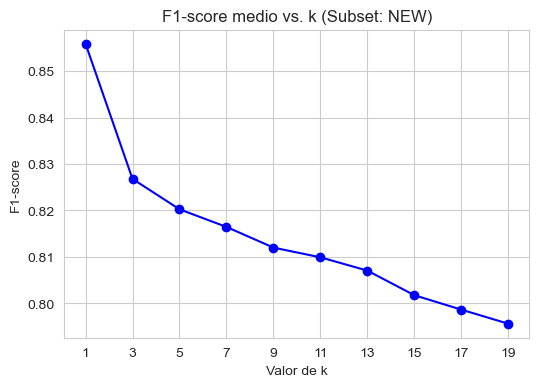

Subset 'Features_destiladas' → Mejor k: 1 | F1 promedio: 0.856


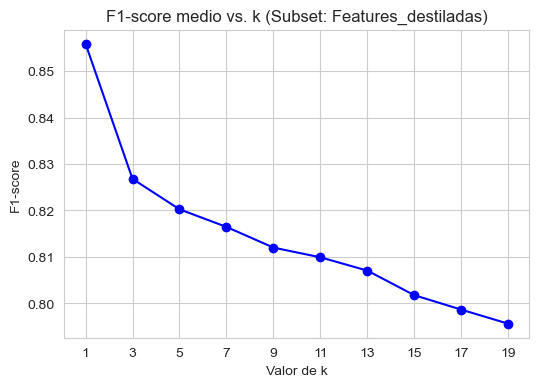

Subset 'Features_destiladas_con_nueva' → Mejor k: 1 | F1 promedio: 0.856


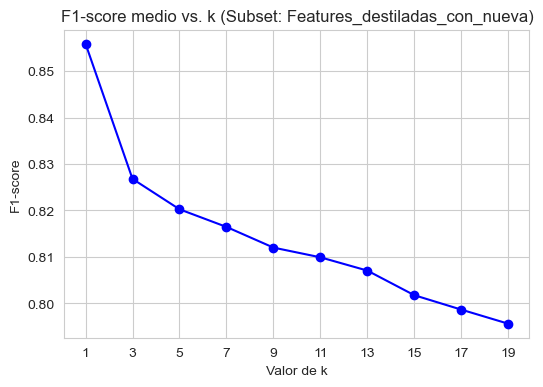

['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos Balanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.706      0.819   0.770   
1                           Todo     Churn     0.706      0.454   0.530   
2                            NEW  Continua     0.692      0.817   0.749   
3                            NEW     Churn     0.692      0.435   0.535   
4            Features_destiladas  Continua     0.721      0.757   0.914   
5            Features_destiladas     Churn     0.721      0.443   0.189   
6  Features_destiladas_con_nueva  Continua     0.721      0.757   0.914   
7  Features_destiladas_con_nueva     Churn     0.721      0.443   0.189   

   F1-score       Modelo  
0     0.794  KNN (SMOTE)  
1     0.489  KNN (SMOTE)  
2     0.781  KNN (SMOTE)  
3     0.480  KNN (SMOTE)  
4     0.828  KNN (SMOTE)  
5     0.265  KNN (SMOTE)  
6     0.828  KNN (SMOTE)  
7     

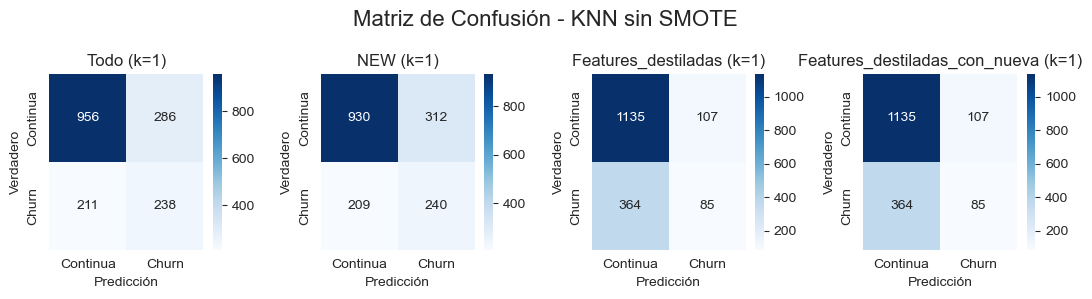

In [44]:
k_values = range(1, 20, 2) # Probar k de 1 a 11 (impares)

best_k_por_subset = {}
scores_por_subset = {}

datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresKNNSMOTE)
DTX_resampled_smote, _, DTy_resampled_smote, _ = SMOTEdatasets['Todo']
#Busco el mejor k con validación cruzada

for nombre, X in features.items():
    accuracies_cv = []
    for k_val in k_values:
        scores = cross_val_score(KNeighborsClassifier(n_neighbors=k_val),  DTX_resampled_smote, DTy_resampled_smote, cv=5, scoring='f1')
        # guardar el mejor k por subset
        accuracies_cv.append(scores.mean()) # Guardar la media de las puntuaciones de CV

    # Guardar resultados
    scores_por_subset[nombre] = accuracies_cv
    best_k_cv = k_values[np.argmax(accuracies_cv)]
    best_k_por_subset[nombre] = best_k_cv
    
    print(f"Subset '{nombre}' → Mejor k: {best_k_cv} | F1 promedio: {max(accuracies_cv):.3f}")

    # Graficar resultados de este subset
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, accuracies_cv, marker='o', linestyle='-', color='b')
    plt.title(f'F1-score medio vs. k (Subset: {nombre})')
    plt.xlabel('Valor de k')
    plt.ylabel('F1-score')
    plt.xticks(k_values)
    plt.grid(True)
    plt.show()


KNN = KNeighborsClassifier(n_neighbors=best_k_cv)

resultados = []
roc_auc_KNN_SMOTE = ['KNN_SMOTE']
fpr_KNN_SMOTE = []
tpr_KNN_SMOTE = []
thresholds_KNN_SMOTE = []

for set_dato, (X_train, X_test, y_train, y_test) in SMOTEdatasets.items():
    KNN.fit(X_train, y_train)
    y_pred = KNN.predict(X_test)
    y_score = KNN.predict_proba(X_test)[:,1]

    roc_auc_KNN_SMOTE.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_KNN_SMOTE.append(fpr)
    tpr_KNN_SMOTE.append(tpr)
    thresholds_KNN_SMOTE.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosKNNS = pd.DataFrame(resultados).round(3)
df_resultadosKNNS['Modelo'] = 'KNN (SMOTE)'


print("Datos Balanceados:\n")
print(df_resultadosKNNS.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosKNNS['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosKNNS[df_resultadosKNNS['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre} (k={best_k_por_subset[nombre]})')

plt.suptitle('Matriz de Confusión - KNN sin SMOTE', fontsize=16)
plt.tight_layout()
plt.show()


Se mejoró el recall de Churn pero se redujo la accuracy en general.

El procedimiento se repite para el resto de los modelos.

## Modelo Regresión Logística

### Sin datos balanceados

In [45]:
LogReg = LogisticRegression()

resultados= [] #Reinicio de la variable resultados

for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):
    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista
       
        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)

        LogReg.fit(X_train, y_train)
        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(LogReg,X_train, y_train, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfLogReg = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfLogReg[scores_dfLogReg["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalLogReg = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresLogReg = best_globalLogReg["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalLogReg['Features']}")
print(f"F1-score: {best_globalLogReg['F1-score']:.3f} | Recall: {best_globalLogReg['Recall']:.3f} | Accuracy: {best_globalLogReg['Accuracy']:.3f}")



🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month'] | F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776
- 3 features: ['cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.484 | Recall: 0.407 | Accuracy: 0.782

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__InternetService_Fiber optic', 'cat__Contract_Month-to-month']
F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776


['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos desbalanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.805      0.842   0.903   
1                           Todo     Churn     0.805      0.666   0.532   
2                            NEW  Continua     0.776      0.779   0.970   
3                            NEW     Churn     0.776      0.745   0.241   
4            Features_destiladas  Continua     0.765      0.856   0.816   
5            Features_destiladas     Churn     0.765      0.550   0.621   
6  Features_destiladas_con_nueva  Continua     0.765      0.856   0.816   
7  Features_destiladas_con_nueva     Churn     0.765      0.550   0.621   

   F1-score               Modelo  
0     0.872  Logistic Regression  
1     0.592  Logistic Regression  
2     0.864  Logistic Regression  
3     0.364  Logistic Regression  
4     0.836  Logistic Regression  
5     0.5

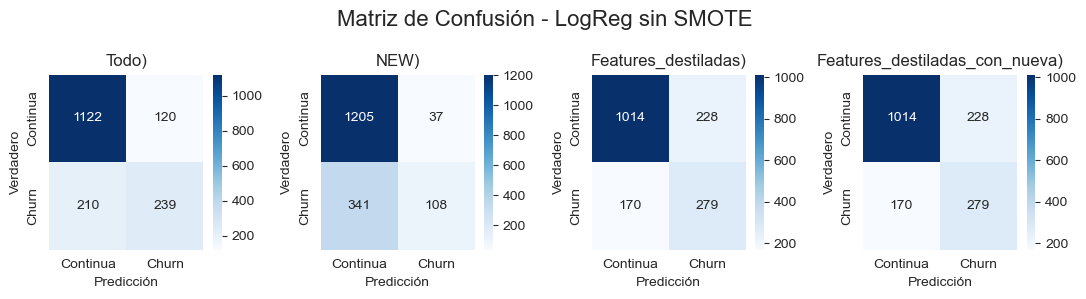

In [76]:
datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresLogReg)

resultados = []
roc_auc_LogReg = ['Logistic Regression']
fpr_LogReg = []
tpr_LogReg = []
thresholds_LogReg = []

for set_dato, (X_train, X_test, y_train, y_test) in datasets.items():
    LogReg.fit(X_train, y_train)
    y_pred = LogReg.predict(X_test)
    y_score = LogReg.predict_proba(X_test)[:,1]

    roc_auc_LogReg.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_LogReg.append(fpr)
    tpr_LogReg.append(tpr)
    thresholds_LogReg.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosLogReg = pd.DataFrame(resultados).round(3)
df_resultadosLogReg['Modelo'] = 'Logistic Regression'

print("Datos desbalanceados:\n")
print(df_resultadosLogReg.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosLogReg['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosLogReg[df_resultadosLogReg['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre})')

plt.suptitle('Matriz de Confusión - LogReg sin SMOTE', fontsize=16)
plt.tight_layout()
plt.show()

### Con datos balanceados (SMOTE)

In [77]:
resultados= []

smote = SMOTE(random_state=42)

features_mejoran_recall = []  # listado de features que suben el recall
X = train_scaled_df4[top_features]


for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):

    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista


        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)

        X_trainSMOTE, y_trainSMOTE = smote.fit_resample(X_train, y_train)

        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(LogReg,X_trainSMOTE, y_trainSMOTE, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfLogRegSMOTE = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfLogRegSMOTE[scores_dfLogRegSMOTE["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalLogRegSMOTE = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresLogRegSMOTE = best_globalLogReg["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalLogRegSMOTE['Features']}")
print(f"F1-score: {best_globalLogRegSMOTE['F1-score']:.3f} | Recall: {best_globalLogRegSMOTE['Recall']:.3f} | Accuracy: {best_globalLogRegSMOTE['Accuracy']:.3f}")


🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.596 | Recall: 0.746 | Accuracy: 0.746
- 3 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.621 | Recall: 0.758 | Accuracy: 0.768
- 4 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.620 | Recall: 0.774 | Accuracy: 0.761
- 5 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.608 | Recall: 0.765 | Accuracy: 0.752

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'cat__InternetService_Fiber optic']
F1-score: 0.621 | Recall: 0.758 | Accuracy: 0.768


['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos Balanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.762      0.901   0.758   
1                           Todo     Churn     0.762      0.536   0.771   
2                            NEW  Continua     0.764      0.853   0.820   
3                            NEW     Churn     0.764      0.550   0.610   
4            Features_destiladas  Continua     0.652      0.923   0.573   
5            Features_destiladas     Churn     0.652      0.424   0.869   
6  Features_destiladas_con_nueva  Continua     0.652      0.923   0.573   
7  Features_destiladas_con_nueva     Churn     0.652      0.424   0.869   

   F1-score                       Modelo  
0     0.824  Logistic Regression (SMOTE)  
1     0.632  Logistic Regression (SMOTE)  
2     0.836  Logistic Regression (SMOTE)  
3     0.579  Logistic Regression (SMOTE)  
4     0

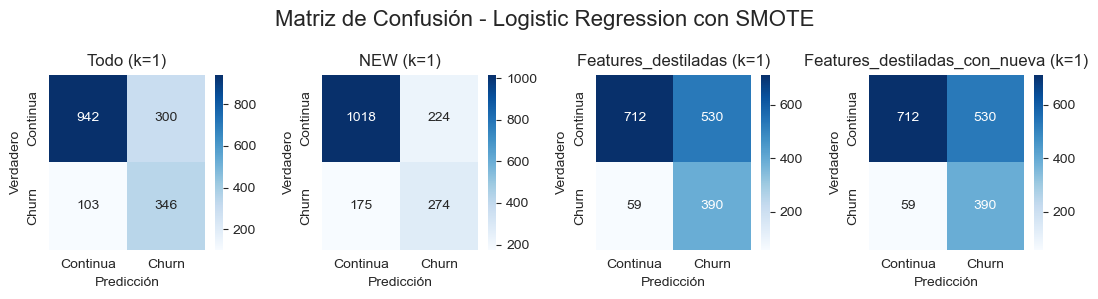

In [78]:
datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresLogRegSMOTE)

resultados = []
roc_auc_LogReg_SMOTE = ['Logistic Regression (SMOTE)']
fpr_LogReg_SMOTE = []
tpr_LogReg_SMOTE = []
thresholds_LogReg_SMOTE = []

for set_dato, (X_train, X_test, y_train, y_test) in SMOTEdatasets.items():
    LogReg.fit(X_train, y_train)
    y_pred = LogReg.predict(X_test)
    y_score = LogReg.predict_proba(X_test)[:,1]

    roc_auc_LogReg_SMOTE.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_LogReg_SMOTE.append(fpr)
    tpr_LogReg_SMOTE.append(tpr)
    thresholds_LogReg_SMOTE.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosLogRegS = pd.DataFrame(resultados).round(3)
df_resultadosLogRegS['Modelo'] = 'Logistic Regression (SMOTE)'


print("Datos Balanceados:\n")
print(df_resultadosLogRegS.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosLogRegS['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosLogRegS[df_resultadosLogRegS['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre} (k={best_k_por_subset[nombre]})')

plt.suptitle('Matriz de Confusión - Logistic Regression con SMOTE', fontsize=16)
plt.tight_layout()
plt.show()

# Modelo de Naive-Bayes

### Sin datos balanceados

In [79]:
GSB = GaussianNB()

resultados= []

for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):
    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista
       
        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)

        GSB.fit(X_train, y_train)
        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(GSB,X_train, y_train, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfGSB = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfGSB[scores_dfGSB["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalGSB = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresGSB = best_globalGSB["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalGSB['Features']}")
print(f"F1-score: {best_globalGSB['F1-score']:.3f} | Recall: {best_globalGSB['Recall']:.3f} | Accuracy: {best_globalGSB['Accuracy']:.3f}")


🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['cat__Contract_Month-to-month', 'cat__InternetService_Fiber optic'] | F1-score: 0.585 | Recall: 0.628 | Accuracy: 0.776
- 3 features: ['cat__Contract_Month-to-month', 'num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.605 | Recall: 0.760 | Accuracy: 0.751
- 4 features: ['cat__Contract_Month-to-month', 'num__tenure', 'cat__InternetService_Fiber optic', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.595 | Recall: 0.668 | Accuracy: 0.771
- 5 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.589 | Recall: 0.579 | Accuracy: 0.797

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__Contract_Month-to-month', 'num__tenure', 'cat__InternetService_Fiber optic']
F1-score: 0.605 | Recall: 0.760 | Accuracy: 0.751


['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos desbalanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.746      0.900   0.736   
1                           Todo     Churn     0.746      0.514   0.773   
2                            NEW  Continua     0.769      0.774   0.969   
3                            NEW     Churn     0.769      0.719   0.216   
4            Features_destiladas  Continua     0.751      0.897   0.747   
5            Features_destiladas     Churn     0.751      0.521   0.762   
6  Features_destiladas_con_nueva  Continua     0.768      0.787   0.938   
7  Features_destiladas_con_nueva     Churn     0.768      0.635   0.298   

   F1-score       Modelo  
0     0.810  Gaussian NB  
1     0.617  Gaussian NB  
2     0.861  Gaussian NB  
3     0.332  Gaussian NB  
4     0.815  Gaussian NB  
5     0.619  Gaussian NB  
6     0.856  Gaussian NB  
7  

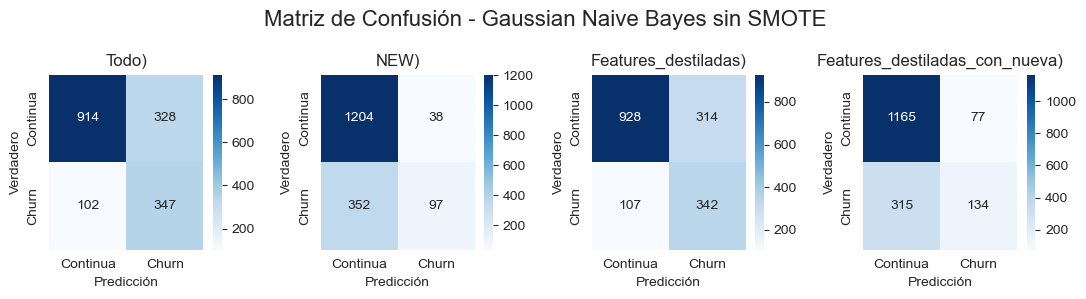

In [80]:
datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresGSB)

resultados = []
roc_auc_GSB = ['Gaussian NB']
fpr_GSB = []
tpr_GSB = []
thresholds_GSB = []

for set_dato, (X_train, X_test, y_train, y_test) in datasets.items():
    GSB.fit(X_train, y_train)
    y_pred = GSB.predict(X_test)
    y_score = GSB.predict_proba(X_test)[:,1]

    roc_auc_GSB.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_GSB.append(fpr)
    tpr_GSB.append(tpr)
    thresholds_GSB.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosGSB = pd.DataFrame(resultados).round(3)
df_resultadosGSB['Modelo'] = 'Gaussian NB'

print("Datos desbalanceados:\n")
print(df_resultadosGSB.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosGSB['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosGSB[df_resultadosGSB['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre})')

plt.suptitle('Matriz de Confusión - Gaussian Naive Bayes sin SMOTE', fontsize=16)
plt.tight_layout()
plt.show()

### Con datos balanceados (SMOTE)

In [81]:
resultados= []

smote = SMOTE(random_state=42)

features_mejoran_recall = []  # listado de features que suben el recall
X = train_scaled_df4[top_features]


for perm_idx, selected in enumerate(iter.permutations(X.columns), start=1):

    for i in range(1, len(top_features)+1):
        subset = list(selected[:i])  # convertir Index a lista

        X_train, X_test, y_train, y_test = train_test_split(train_scaled_df4[subset], train_scaled_df4['cat__Churn_Yes'], test_size=0.3, random_state=42)

        X_trainSMOTE, y_trainSMOTE = smote.fit_resample(X_train, y_train)

        #model, X_train,y_train, X_test, y_test, feature, resultados=[], target_names = None, contador=None
        resultados = reporte_modelo(GSB,X_trainSMOTE, y_trainSMOTE, X_test, y_test, subset, resultados, target_names,f"perm {perm_idx} step {i}")

# Convertir resultados a DataFrame
scores_dfGSBSMOTE = pd.DataFrame(resultados).round(3)

# Filtrar solo la clase churn y mínimo 2 features
df_churn = scores_dfGSBSMOTE[scores_dfGSB["Clase"].str.contains("churn", case=False)]
df_churn = df_churn[df_churn["Features"].apply(lambda f: len(f) >= 2)]

# Encontrar la mejor combinación para cada tamaño de features
best_by_size = df_churn.groupby(df_churn["Features"].apply(len)).apply(
    lambda g: g.loc[g["F1-score"].idxmax()]
)

print("\n🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):")
for _, row in best_by_size.iterrows():
    print(f"- {len(row['Features'])} features: {row['Features']} | "
          f"F1-score: {row['F1-score']:.3f} | Recall: {row['Recall']:.3f} | Accuracy: {row['Accuracy']:.3f}")

# Mejor combinación global (independientemente del tamaño)
best_globalGSBSMOTE = df_churn.loc[df_churn["F1-score"].idxmax()]
best_global_featuresGSBSMOTE = best_globalGSB["Features"]

print("\n🥇 Mejor combinación global de features por F1-score:")
print(f"Features: {best_globalGSBSMOTE['Features']}")
print(f"F1-score: {best_globalGSBSMOTE['F1-score']:.3f} | Recall: {best_globalGSBSMOTE['Recall']:.3f} | Accuracy: {best_globalGSBSMOTE['Accuracy']:.3f}")


🏆 Mejores combinaciones de features para maximizar el F1-score de churn (mínimo 2):
- 2 features: ['num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.596 | Recall: 0.746 | Accuracy: 0.746
- 3 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.622 | Recall: 0.753 | Accuracy: 0.770
- 4 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic'] | F1-score: 0.609 | Recall: 0.734 | Accuracy: 0.763
- 5 features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'num__tenure', 'cat__InternetService_Fiber optic', 'cat__PaymentMethod_Electronic check'] | F1-score: 0.609 | Recall: 0.741 | Accuracy: 0.761

🥇 Mejor combinación global de features por F1-score:
Features: ['cat__Contract_Month-to-month', 'NEW_MonthlyCharges_Tenure', 'cat__InternetService_Fiber optic']
F1-score: 0.622 | Recall: 0.753 | Accuracy: 0.770


['Modelo', 'Todo', 'NEW', 'Features_destiladas', 'Features_destiladas_con_nueva']
Datos Balanceados:

                         Dataset     Clase  Accuracy  Precision  Recall  \
0                           Todo  Continua     0.742      0.902   0.727   
1                           Todo     Churn     0.742      0.509   0.782   
2                            NEW  Continua     0.768      0.804   0.904   
3                            NEW     Churn     0.768      0.595   0.390   
4            Features_destiladas  Continua     0.677      0.913   0.618   
5            Features_destiladas     Churn     0.677      0.442   0.837   
6  Features_destiladas_con_nueva  Continua     0.651      0.923   0.572   
7  Features_destiladas_con_nueva     Churn     0.651      0.423   0.869   

   F1-score               Modelo  
0     0.805  Gaussian NB (SMOTE)  
1     0.616  Gaussian NB (SMOTE)  
2     0.851  Gaussian NB (SMOTE)  
3     0.471  Gaussian NB (SMOTE)  
4     0.737  Gaussian NB (SMOTE)  
5     0.579 

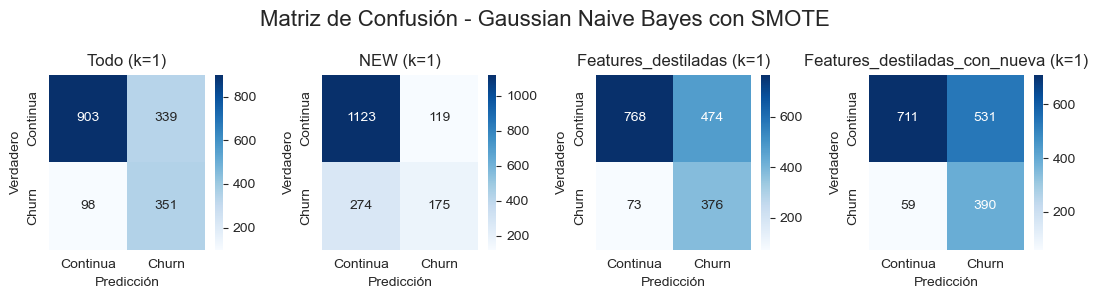

In [82]:
datasets, SMOTEdatasets, features = preparar_datos_modelado(train_scaled_df4,best_global_featuresGSBSMOTE)

resultados = []
roc_auc_GSB_SMOTE = ['Gaussian NB (SMOTE)']
fpr_GSB_SMOTE = []
tpr_GSB_SMOTE = []
thresholds_GSB_SMOTE = []

for set_dato, (X_train, X_test, y_train, y_test) in SMOTEdatasets.items():
    GSB.fit(X_train, y_train)
    y_pred = GSB.predict(X_test)
    y_score = GSB.predict_proba(X_test)[:,1]

    roc_auc_GSB_SMOTE.append(roc_auc_score(y_test,y_score))
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    fpr_GSB_SMOTE.append(fpr)
    tpr_GSB_SMOTE.append(tpr)
    thresholds_GSB_SMOTE.append(thresholds)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Guardar métricas principales
    for clase in target_names:  # ['continua', 'churn']
        resultados.append({
            "Dataset": set_dato,
            "Clase": clase,
            "Accuracy": accuracy,
            "Precision": report[clase]['precision'],
            "Recall": report[clase]['recall'],
            "F1-score": report[clase]['f1-score'],
            "ConfusionMatrix": cm
    })
# Convertir a DataFrame
print(titulos)
df_resultadosGSBS = pd.DataFrame(resultados).round(3)
df_resultadosGSBS['Modelo'] = 'Gaussian NB (SMOTE)'


print("Datos Balanceados:\n")
print(df_resultadosGSBS.drop(columns=['ConfusionMatrix']))


unicos_datasets = df_resultadosGSBS['Dataset'].unique()

fig, axes = plt.subplots(1, len(features), figsize=(11, 3))

for ax, nombre in zip(axes, unicos_datasets):
    subset = df_resultadosGSBS[df_resultadosGSBS['Dataset'] == nombre].iloc[0]
    cm = subset["ConfusionMatrix"]
    nombre = subset["Dataset"]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdadero')
    ax.set_title(f'{nombre} (k={best_k_por_subset[nombre]})')

plt.suptitle('Matriz de Confusión - Gaussian Naive Bayes con SMOTE', fontsize=16)
plt.tight_layout()
plt.show()

## Resumen

Resultados finales combinados de todos los modelos:



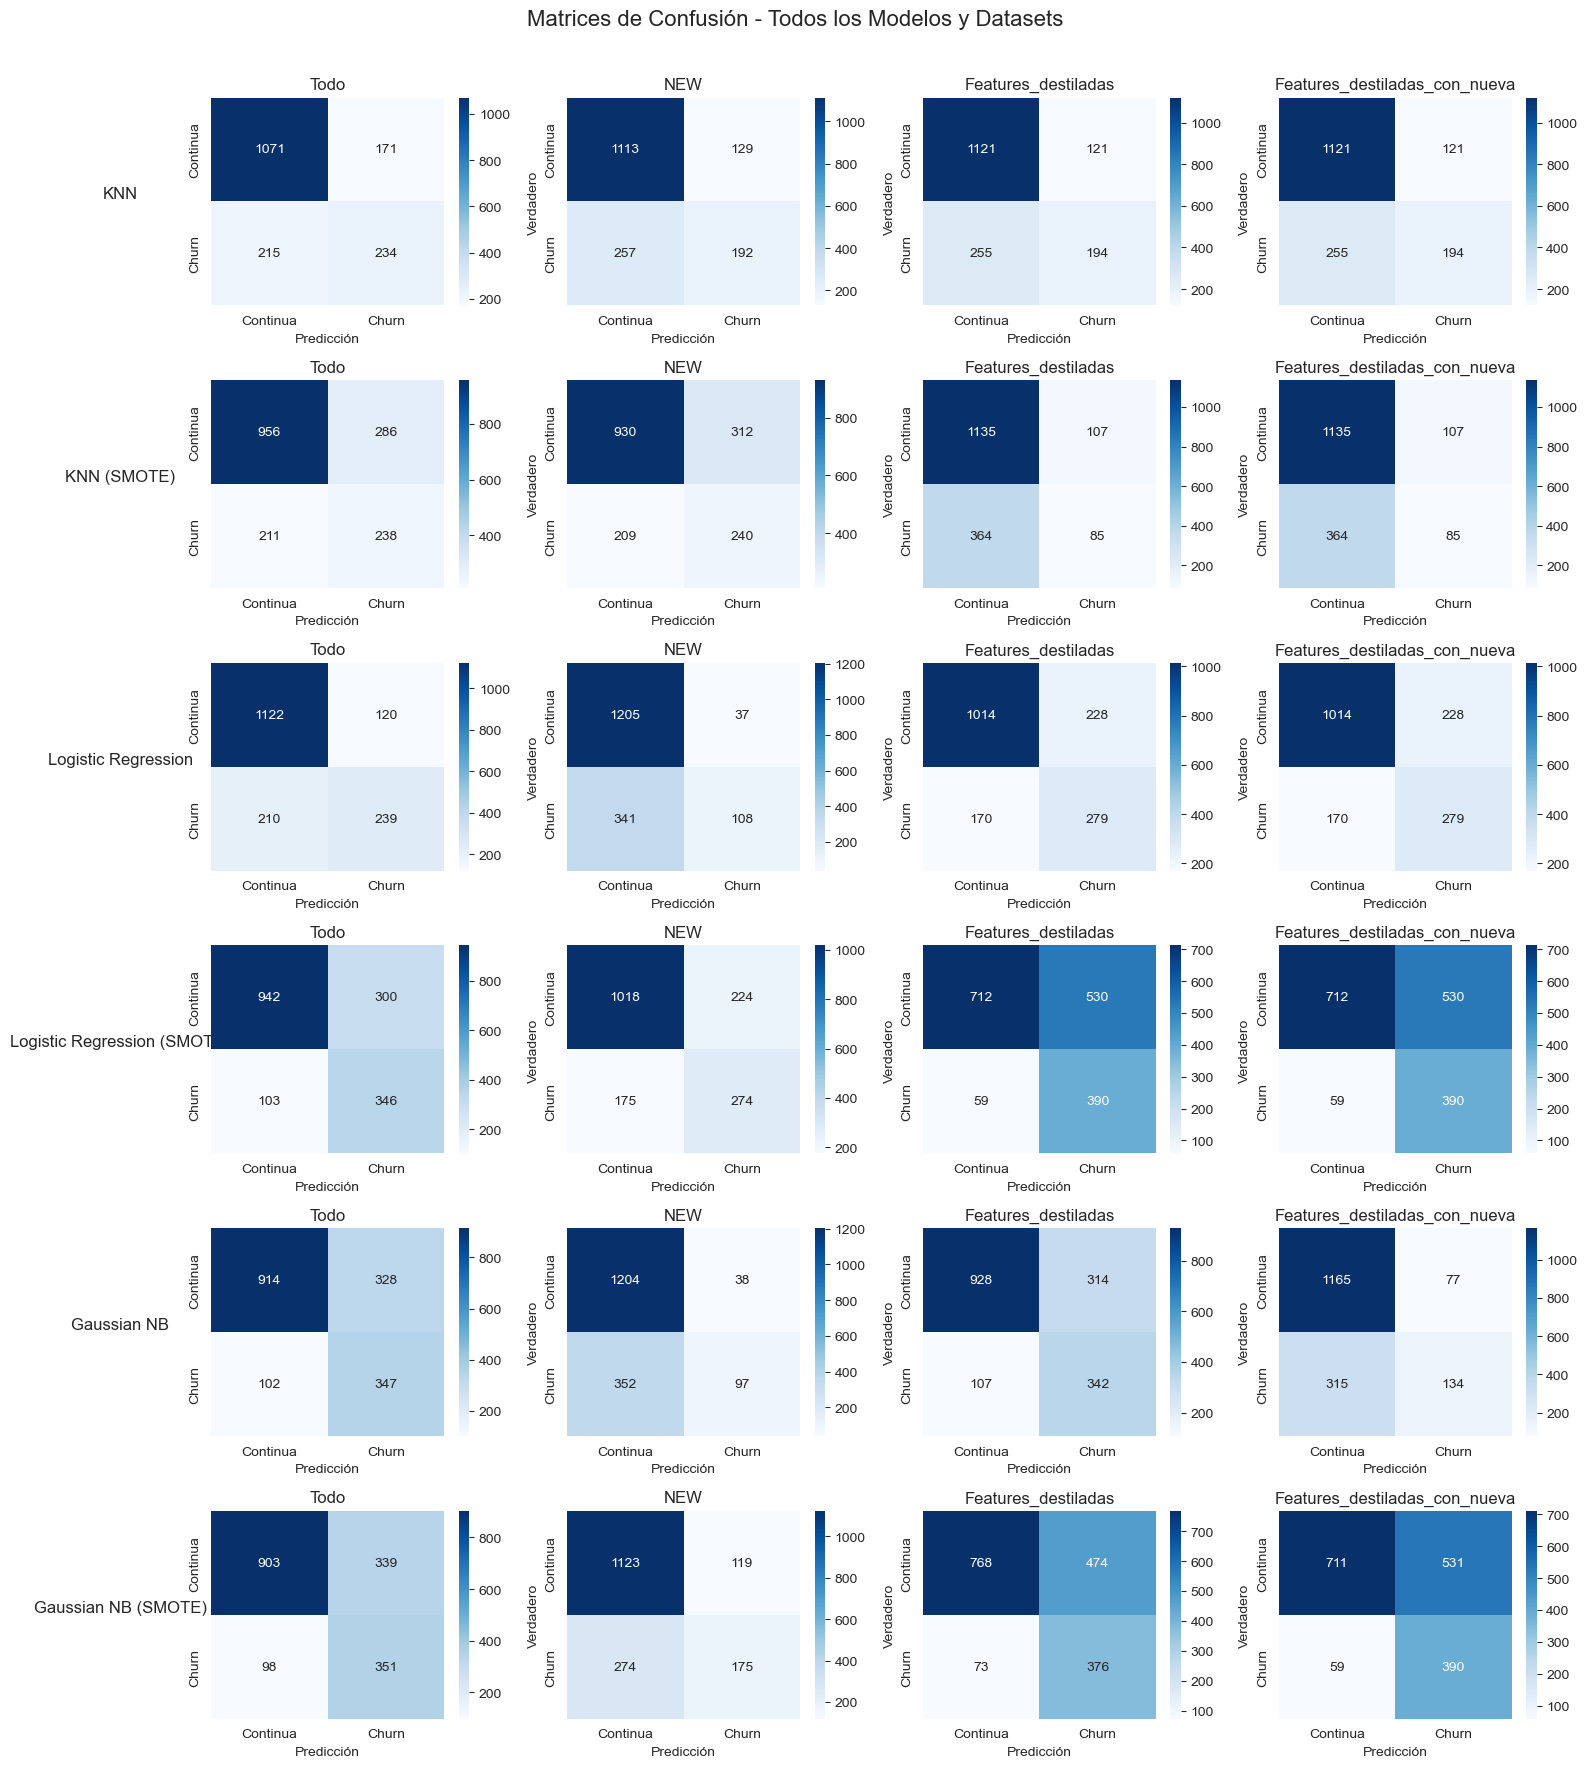

,Dataset,Clase,Accuracy,Precision,Recall,F1-score,Modelo
18,NEW,Continua,0.776,0.779,0.970,0.864,Logistic Regression
34,NEW,Continua,0.769,0.774,0.969,0.861,Gaussian NB
38,Features_destiladas_con_nueva,Continua,0.768,0.787,0.938,0.856,Gaussian NB
12,Features_destiladas,Continua,0.721,0.757,0.914,0.828,KNN (SMOTE)
14,Features_destiladas_con_nueva,Continua,0.721,0.757,0.914,0.828,KNN (SMOTE)
42,NEW,Continua,0.768,0.804,0.904,0.851,Gaussian NB (SMOTE)
16,Todo,Continua,0.805,0.842,0.903,0.872,Logistic Regression
4,Features_destiladas,Continua,0.778,0.815,0.903,0.856,KNN
6,Features_destiladas_con_nueva,Continua,0.778,0.815,0.903,0.856,KNN
2,NEW,Continua,0.772,0.812,0.896,0.852,KNN


In [83]:
resultados_finales = pd.concat([df_resultadosKNN, df_resultadosKNNS, df_resultadosLogReg, df_resultadosLogRegS, df_resultadosGSB, df_resultadosGSBS], ignore_index=True)
modelos = resultados_finales['Modelo'].unique()
datasets = resultados_finales['Dataset'].unique()

print("Resultados finales combinados de todos los modelos:\n")
#print(resultados_finales.drop(columns=['ConfusionMatrix'])) 

fig, axes = plt.subplots(len(modelos), len(datasets), figsize=(4*len(datasets), 3*len(modelos)))
if len(modelos) == 1:
    axes = [axes]  # una sola fila
else:
    axes = axes  # matriz de ejes


for i, modelo in enumerate(modelos):
    for j, dataset in enumerate(datasets):
        ax = axes[i][j] if len(modelos) > 1 else axes[j]
        
        # Filtrar resultados para ese modelo y dataset
        subset = resultados_finales[
            (resultados_finales['Modelo'] == modelo) &
            (resultados_finales['Dataset'] == dataset)
        ].iloc[0]
        
        cm = subset["ConfusionMatrix"]
        
        # Dibujar heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Verdadero')
        ax.set_title(f'{dataset}')

    # Título general por fila (modelo)
    axes[i][0].set_ylabel(modelo, fontsize=12, rotation=0, labelpad=50)


# Título global
plt.suptitle('Matrices de Confusión - Todos los Modelos y Datasets', fontsize=16, y=0.98)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

resultados_finales.sort_values(by=['Clase', 'Recall', 'Accuracy'], ascending=False,inplace=True)
resultados_finales.drop(columns=['ConfusionMatrix']).round(3)

Valores de evaluación ROC - AUC


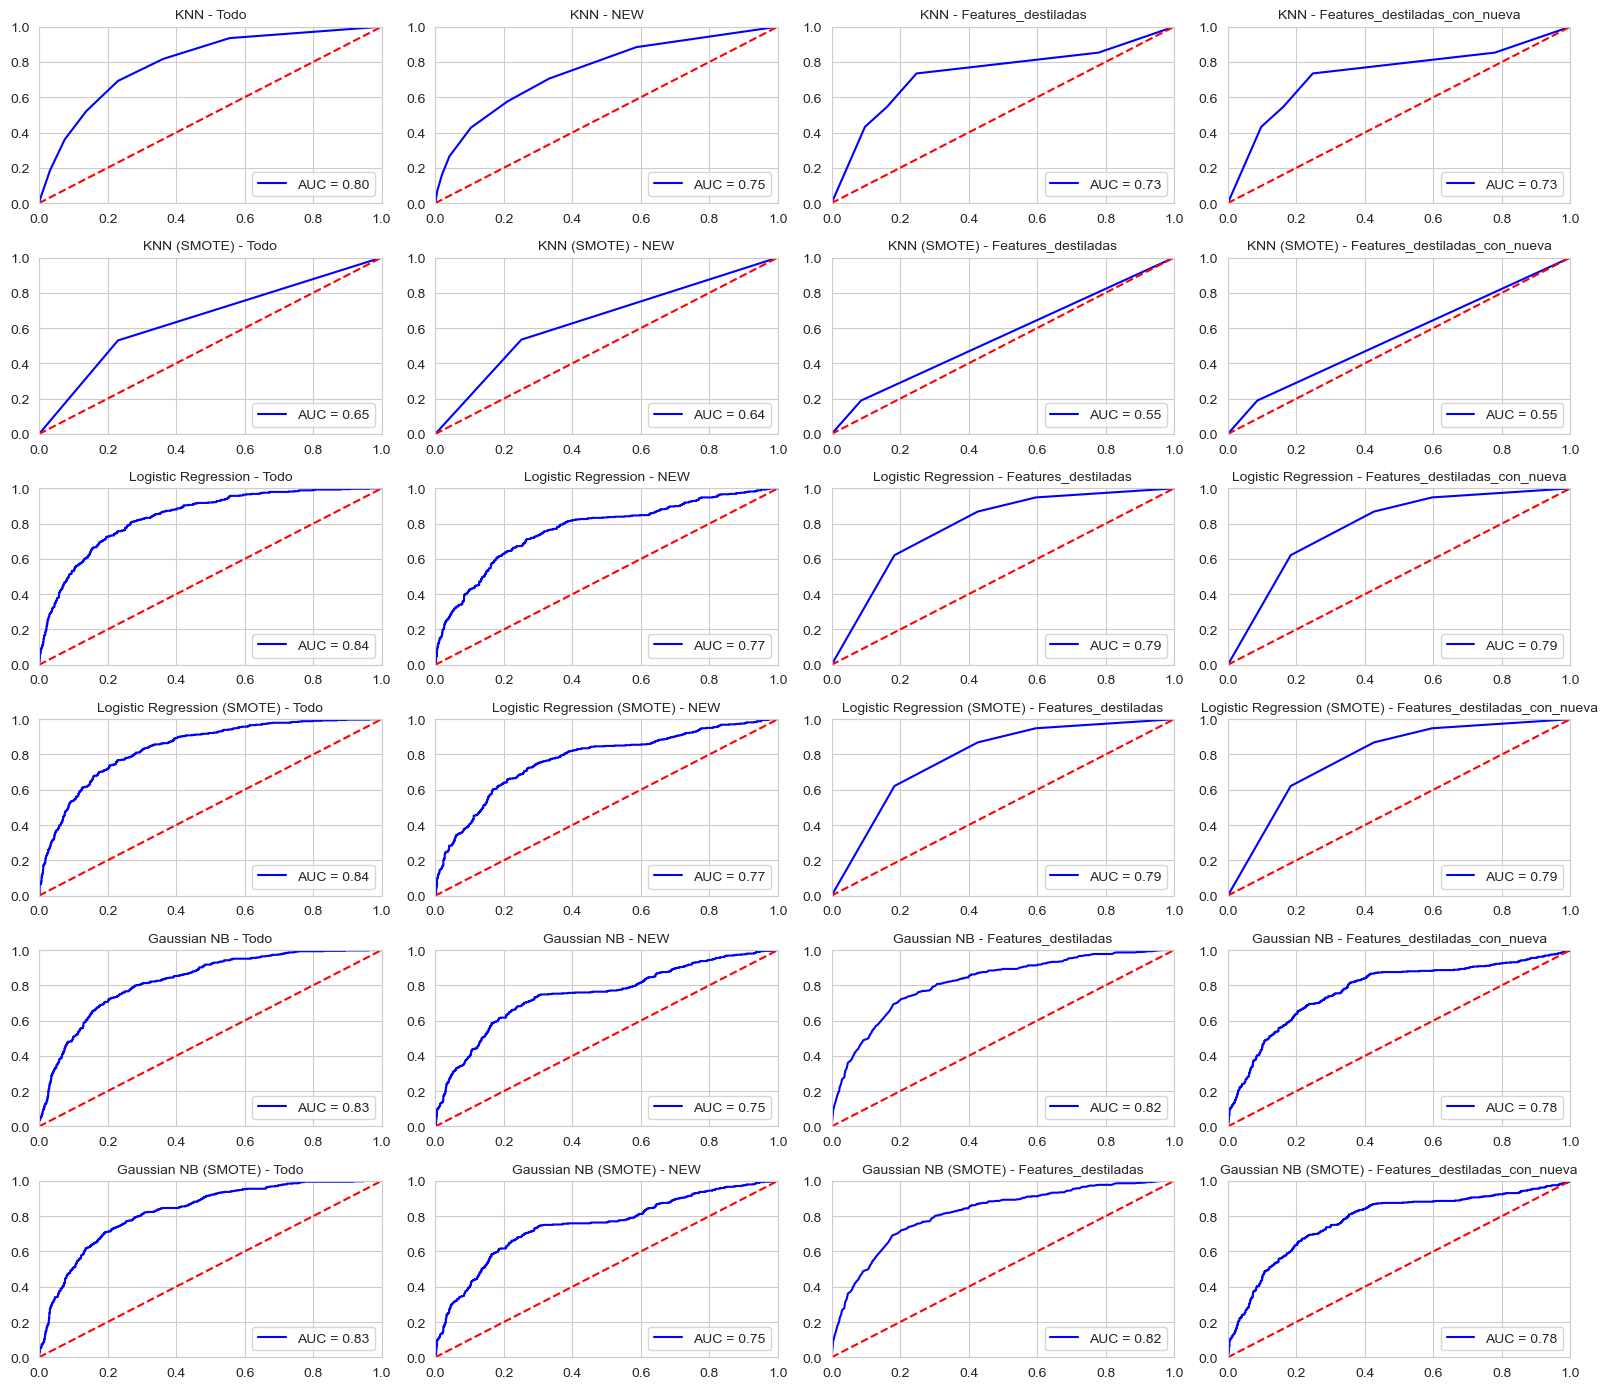

,Modelo,Todo,NEW,Features_destiladas,Features_destiladas_con_nueva
0,KNN,0.798,0.751,0.734,0.734
1,KNN_SMOTE,0.650,0.642,0.552,0.552
2,Logistic Regression,0.841,0.769,0.786,0.786
3,Logistic Regression (SMOTE),0.841,0.773,0.786,0.786
4,Gaussian NB,0.829,0.750,0.818,0.776
5,Gaussian NB (SMOTE),0.829,0.750,0.817,0.776


In [84]:
df_rocaucResumen = pd.DataFrame([roc_auc_KNN,roc_auc_KNN_SMOTE,roc_auc_LogReg,roc_auc_LogReg_SMOTE, roc_auc_GSB, roc_auc_GSB_SMOTE], columns=titulos)
print('Valores de evaluación ROC - AUC')


fpr_total = [fpr_KNN,fpr_KNN_SMOTE,fpr_LogReg,fpr_LogReg_SMOTE,fpr_GSB,fpr_GSB_SMOTE]
tpr_total = [tpr_KNN,tpr_KNN_SMOTE,tpr_LogReg,tpr_LogReg_SMOTE,tpr_GSB,tpr_GSB_SMOTE]
thresholds_total =[thresholds_KNN,thresholds_KNN_SMOTE,thresholds_LogReg,thresholds_LogReg_SMOTE,thresholds_GSB,thresholds_GSB_SMOTE]

auc_KNN = roc_auc_KNN[1:]
auc_KNN_SMOTE = roc_auc_KNN_SMOTE[1:]
auc_LogReg = roc_auc_LogReg[1:]
auc_LogReg_SMOTE = roc_auc_LogReg_SMOTE[1:]
auc_GSB = roc_auc_GSB[1:]
auc_GSB_SMOTE = roc_auc_GSB_SMOTE[1:]

datos = {
    "KNN": (fpr_KNN, tpr_KNN, auc_KNN),
    "KNN (SMOTE)": (fpr_KNN_SMOTE, tpr_KNN_SMOTE, auc_KNN_SMOTE),
    "Logistic Regression": (fpr_LogReg,tpr_LogReg,auc_LogReg),
    "Logistic Regression (SMOTE)": (fpr_LogReg_SMOTE,tpr_LogReg_SMOTE,auc_LogReg_SMOTE),
    "Gaussian NB": (fpr_GSB,tpr_GSB,auc_GSB),
    "Gaussian NB (SMOTE)": (fpr_GSB_SMOTE,tpr_GSB_SMOTE,auc_GSB_SMOTE)
}

curvas = {}
for modelo, (fprs, tprs, aucs) in datos.items():
    for i, dataset in enumerate(datasets):
        curvas[(modelo, dataset)] = (fprs[i], tprs[i], aucs[i])


# Crear grilla
fig, axes = plt.subplots(nrows=len(modelos), ncols=len(datasets), figsize=(16, 14))

for i, modelo in enumerate(modelos):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        fpr, tpr, auc = curvas[(modelo, dataset)]
        
        ax.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.2f}")
        ax.plot([0, 1], [0, 1], color='red', linestyle='--')
        ax.set_title(f"{modelo} - {dataset}", fontsize=10)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.legend(loc="lower right")
        ax.grid(True)

plt.tight_layout()
plt.show()

df_rocaucResumen.round(3)



#  **5. Selección de Modelo**

## Basado en tus resultados de validación, se eligió el mejor modelo re-entrenandolo con el mejor dataset (**todos los datos de `train.csv`**) y se utilizó para hacer predicciones sobre `test.csv` (generando un archivo csv con dichas predicciones e ID de clientes).


In [22]:
# Crear copias de los DataFrames originales para preservar los datos sin modificaciones
test_df1 = test_df.copy()

#Remoción de la columna 'customerID' (no aporta valor predictivo)
test_df1.drop(columns=['customerID'], inplace=True) 

# Identificar columnas categóricas y numéricas
categorical_cols = test_df1.select_dtypes(include=['object', 'category']).columns
numeric_cols = test_df1.select_dtypes(include=['int64', 'float64']).columns

# Crear encoder
ohe = OneHotEncoder(drop='if_binary',handle_unknown='ignore', sparse_output=False)

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, categorical_cols),   # aplica OHE solo a categóricas
        ('num', 'passthrough', numeric_cols)  # deja numéricas igual
    ]
)

# Ajustar con test y transformar ambos
test_encoded = preprocessor.fit_transform(test_df1)

# Convertir a DataFrame con nombres de columnas
test_encoded_df2 = pd.DataFrame(test_encoded, 
                                columns=preprocessor.get_feature_names_out(test_df1.columns),
                                index=test_df1.index)

# Identifico todas las columnas que continen "No internet service"
cols_to_drop = [col for col in test_encoded_df2.columns 
                if "No" in col and col != "cat__InternetService_No"
]

test_encoded_df3 = test_encoded_df2.copy()
# Elimino esas columnas junto con la columna de "No phone service"
test_encoded_df3.drop(columns=cols_to_drop, inplace=True)

#Estandarizo las columnas numéricas
test_encoded_df4 = test_encoded_df3.copy()


# Al estandarizar se busco hacer dicho proceso solo con las columnas numéricas no binarias
# 1. Detectar columnas binarias
binary_cols = [col for col in test_encoded_df4.columns 
               if test_encoded_df4[col].dropna().nunique() == 2]

# 2. Seleccionar columnas numéricas no binarias
numeric_cols = test_encoded_df4.select_dtypes(include=['float64','int']).drop(columns=binary_cols)

# 3. Escalar solo las numéricas no binarias
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(numeric_cols)

# 4. Reconstruir DataFrame
test_scaled_df4 = pd.DataFrame(
    scaled_numeric,
    columns=numeric_cols.columns,
    index=test_encoded_df4.index
)

# 5. Agregar columnas binarias sin modificar
test_scaled_df4 = pd.concat([test_scaled_df4, test_encoded_df4[binary_cols]], axis=1)

# 6. Mantener el orden original
test_scaled_df4 = test_scaled_df4[test_encoded_df4.columns]

train_scaled_df5 = train_scaled_df4.copy()
y_train = train_scaled_df5['cat__Churn_Yes']
X_train = train_scaled_df5.drop(columns=['cat__Churn_Yes' , 'NEW_MonthlyCharges_Tenure', 'Nivel_de_Servicio'])

LogReg = LogisticRegression()

LogReg.fit(X_train, y_train)

y_pred = LogReg.predict(test_scaled_df4)
y_score = LogReg.predict_proba(test_scaled_df4)[:,1]

y_pred_series = pd.Series(y_pred, name="Prediccion")
y_score_series = pd.Series(y_score, name="Probabilidad")


predicciones_test = pd.concat([test_df['customerID'] , y_pred_series, y_score_series], axis=1)

predicciones_test.to_csv("predicciones_churn.csv", index=False, encoding="utf-8")

predicciones_test

,customerID,Prediccion,Probabilidad
0,4376-KFVRS,0.0,0.045476
1,2754-SDJRD,1.0,0.680171
2,9917-KWRBE,0.0,0.060361
3,0365-GXEZS,0.0,0.393075
4,9385-NXKDA,0.0,0.020913
...,...,...,...
1404,5204-HMGYF,0.0,0.038896
1405,9950-MTGYX,0.0,0.018037
1406,3675-EQOZA,0.0,0.153431
1407,3646-ITDGM,0.0,0.004377


#  **6. Conclusiones**

## 6.1. Sustento de la Selección del Modelo
**Modelo Elegido:** Tras evaluar los tres algoritmos solicitados (Regresión Logística, k-NN y Naive Bayes) de manera exhaustiva (probando distintas variaciones del dataset), determinamos que la Regresión Logística es la herramienta más eficaz para este problema.

**Desempeño:** Basamos nuestra decisión en la métrica ROC AUC, donde este modelo obtuvo el rendimiento más alto (0.84), demostrando una capacidad superior para distinguir entre clientes que abandonan y clientes leales.

**Justificación:** Validamos que este algoritmo maneja de forma óptima las variables categóricas procesadas. Además, su naturaleza nos permite interpretar los coeficientes para entender no solo "quién" se va, sino "por qué".

## 6.2. Hallazgos del Análisis Exploratorio y Modelado
**El peso del contrato:** Confirmamos que el tipo de contrato es el predictor más fuerte. Identificamos que los contratos anuales actúan como un factor de retención crítico, mientras que la modalidad mes a mes eleva el riesgo de abandono.

**Relación de Permanencia:** Validamos una relación inversa clara; a medida que aumenta la antigüedad (tenure), disminuye la probabilidad de Churn. Los primeros meses resultan ser el periodo de mayor vulnerabilidad.

**Servicios de Internet:** Observamos un hallazgo interesante en los usuarios de fibra óptica, quienes presentan una mayor tendencia al abandono, lo que sugiere una oportunidad de mejora en la propuesta de valor y/o experiencia del Cliente para ese segmento.

## 6.3. Rigurosidad Técnica y Soluciones
**Automatización del Flujo:** Se generaron funciones que realizan operaciones repetitivas para todos los modelos a fin de reducir lineas de código y automatizar el proceso para futuros datasets.

**Metodología de Evaluación:** Ante la ausencia de la variable objetivo en el archivo de test, aplicamos una partición interna al archivo train (80/20) para obtener métricas reales y confiables antes de generar las predicciones finales solicitadas.
